# DASH: Diversified Aggregation of SHAP
## Experimental Validation Notebook

**Caraker, Arnold, Rhoads (2026)**

This notebook runs the core experiments validating the DASH method and explains what each result means.

### The Problem

When you train an XGBoost model on data with correlated features, the model picks *one* feature from each correlated group at each split point. Which one it picks is essentially arbitrary — feature A and feature B carry the same signal, and the model grabs whichever gives a marginal gain advantage at that specific split. Change the hyperparameters slightly and the model picks different members of the correlated group. The predictions barely change, but the SHAP values shift dramatically.

This is the Rashomon effect applied to explanations: many models fit the data equally well, but they tell completely different stories about *which features matter*.

### How DASH Works

Instead of trusting one model's arbitrary feature selection, DASH deliberately trains a population of models that are *forced* to use different features by restricting `colsample_bytree` to low values (0.1–0.5). After filtering for performance and selecting for diversity, their SHAP matrices are averaged element-wise. The consensus explanation fairly distributes importance across correlated groups rather than concentrating it on whichever member one model happened to grab.

### What We Test

1. **Correlation Sweep** — The central claim: DASH advantage grows with collinearity, including a ρ=0 safety control
2. **Overlapping Correlation** — Robustness beyond idealized block-diagonal structures
3. **Nonlinear DGP** — DASH works with complex, non-additive relationships
4. **Real Data** — California Housing (regression) and Breast Cancer (classification with heavy natural collinearity)

See `EXPERIMENT_GUIDE.md` for the full rationale behind every experimental choice.

> **Reproducibility**: Run the environment cell below to record package versions and platform info.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy.stats import spearmanr
import warnings, time, sys, platform

# A1: Record environment for reproducibility
print(f'Python:      {sys.version}')
print(f'Platform:    {platform.platform()}')
for pkg_name, pkg in [('numpy', np), ('pandas', pd), ('matplotlib', matplotlib),
                       ('seaborn', sns)]:
    print(f'{pkg_name:12s} {pkg.__version__}')
import xgboost, shap, sklearn, scipy
for pkg_name, pkg in [('xgboost', xgboost), ('shap', shap),
                       ('scikit-learn', sklearn), ('scipy', scipy)]:
    print(f'{pkg_name:12s} {pkg.__version__}')

# A2: Scope warnings narrowly (avoid hiding convergence/runtime warnings)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='shap')
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 10

from dash.core.pipeline import DASHPipeline
from dash.core.consensus import compute_consensus
from dash.core.filtering import performance_filter
from dash.core.diversity import (
    get_preliminary_importance, greedy_maxmin_selection,
    cluster_coverage_selection, deduplication_selection,
)
from dash.core.diagnostics import FeatureStabilityIndex, ImportanceStabilityPlot, local_disagreement_map, compute_diagnostics
from dash.experiments.synthetic import generate_synthetic_linear, generate_synthetic_nonlinear
from dash.baselines import (
    SingleBestBaseline, LargeSingleModelBaseline, NaiveAveragingBaseline,
    StochasticRetrainBaseline, EnsembleSHAPBaseline,
)
from dash.evaluation import importance_accuracy, importance_stability, within_group_equity

# B1: Canonical hyperparameter configuration
# All sections derive from this; overrides are documented inline.
PAPER_CONFIG = {
    'M': 200,        # Epsilon sensitivity used canonical M=200
    'K': 30,         # K_eff hits ceiling at K=10 with ε=0.08 — K=30 provides headroom
    'N_REPS': 20,    # Repetitions for stability measurement
    'EPSILON': 0.08,  # Sweet spot: K_eff=10.0±0.0, 114 models passing, flat performance above
    'DELTA': 0.05,    # Unchanged — no sensitivity analysis run on this
    'N_TRIALS_SB': 30,  # B2: SingleBestBaseline hyperparameter trials (consistent everywhere)
    'T_PER_MODEL': 500,  # Trees per model in LargeSingleModel baseline
    'N_ESTIMATORS_ESHAP': 2000,  # Trees for Ensemble SHAP baseline
    'TAU_CLUSTER': 0.3,   # Cluster coverage: within-cluster distance threshold
}

SEED = 42
M = PAPER_CONFIG['M']
K = PAPER_CONFIG['K']
N_REPS = PAPER_CONFIG['N_REPS']
EPSILON = PAPER_CONFIG['EPSILON']
DELTA = PAPER_CONFIG['DELTA']
N_TRIALS_SB = PAPER_CONFIG['N_TRIALS_SB']
feature_names = [f'G{g}_f{j}' for g in range(10) for j in range(5)]

print(f'\nDASH loaded. Config: M={M}, K={K}, N_REPS={N_REPS}, ε={EPSILON}, δ={DELTA}')
_notebook_start = time.time()  # N13: wall-clock timing


Python:      3.13.3 (main, Apr  8 2025, 13:54:08) [Clang 17.0.0 (clang-1700.0.13.3)]
Platform:    macOS-15.7.3-arm64-arm-64bit-Mach-O
numpy        2.4.2
pandas       3.0.1
matplotlib   3.10.8
seaborn      0.13.2
xgboost      3.2.0
shap         0.51.0
scikit-learn 1.8.0
scipy        1.17.1

DASH loaded. Config: M=200, K=30, N_REPS=20, ε=0.08, δ=0.05


/Users/drake.caraker/ds_projects/dash-shap/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 1. Proof of Concept: Synthetic Linear DGP at ρ=0.9

50 features in 10 groups of 5, within-group correlation ρ=0.9. The target is a linear combination of group means with known coefficients descending from 2.0 to 0.0. Because the DGP is linear and symmetric within groups, we know the ground-truth importance: every feature in group g should get importance |β_g|/5.

This is the simplest possible test — if DASH doesn't work here, it won't work anywhere.

In [2]:
X_train, y_train, X_val, y_val, X_test, y_test, groups, true_importance, meta = \
    generate_synthetic_linear(N=5000, rho=0.9, seed=SEED)

print(f"Dataset: {meta['dgp']} DGP, ρ={meta['rho']}")
print(f"  Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"  Beta groups: {meta['beta_groups']}")

# Run DASH MaxMin — D1: use X_test for SHAP (X_val used only for filtering)
dash_maxmin = DASHPipeline(
    M=M, K=K, epsilon=EPSILON, delta=DELTA,
    selection_method='maxmin', task='regression',
    n_jobs=-1, seed=SEED,
)
dash_maxmin.fit(X_train, y_train, X_val, y_val, X_ref=X_test, feature_names=feature_names)

Dataset: linear DGP, ρ=0.9
  Train: (3500, 50), Val: (750, 50), Test: (750, 50)
  Beta groups: [2.  1.5 1.  0.8 0.6 0.4 0.3 0.2 0.1 0. ]
DASH Stage 1: Population Generation
Training 500 models with -1 parallel jobs...


Training:  16%|█████                           | 80/500 [00:21<02:24,  2.91it/s]/Users/drake.caraker/ds_projects/dash-shap/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Training: 100%|███████████████████████████████| 500/500 [03:40<00:00,  2.27it/s]


Population trained. Best: -0.5898, Worst: -1.5457, Mean: -0.7537

DASH Stage 2: Performance Filtering (epsilon=0.08)
Performance filter: 101/500 models within epsilon=0.08 of best (-0.5898)

DASH Stage 3: Diversity Selection (maxmin)
  Diversity threshold reached at K=15 (min_dist=0.0496 < delta=0.05)
MaxMin selection: 15 models selected from 101 candidates

DASH Stage 4: Consensus SHAP (K=15)


Computing SHAP: 100%|███████████████████████████| 15/15 [01:42<00:00,  6.85s/it]

Consensus computed from 15 models. Top 5 features: [1, 3, 4, 2, 0]

DASH Stage 5: Stability Diagnostics

Pipeline complete in 342.4s (Training: 239.4s, SHAP: 102.8s)


### 1.1 Importance-Stability Plot

Each point is a feature, positioned by consensus importance (x) and Feature Stability Index (y). Features colored by true group membership. The four quadrants identify:

- **I: Robust Drivers** (high importance, low FSI) — features whose importance is consistent across models
- **II: Collinear Cluster Members** (high importance, high FSI) — important features whose attribution varies because they're interchangeable with correlated neighbors
- **III: Confirmed Unimportant** (low importance, low FSI) — genuinely unimportant features (group 10, β=0)
- **IV: Fragile Interactions** (low importance, high FSI) — features with unstable, small attributions

At ρ=0.9, most important features should land in quadrant II (collinear), with the FSI serving as an unsupervised collinearity detector.

DASH (MaxMin) vs Ground Truth:
  Spearman ρ:      0.9899
  Within-group CV: 0.1922

Feature Stability Summary
Feature                Importance      FSI
----------------------------------------
G0_f1                      0.3488    0.256
G0_f3                      0.3384    0.231
G0_f4                      0.3215    0.248
G0_f2                      0.3014    0.255
G0_f0                      0.2994    0.234
G1_f3                      0.2548    0.310
G1_f2                      0.2448    0.226
G1_f4                      0.2289    0.315
G1_f0                      0.2230    0.330
G1_f1                      0.1839    0.327


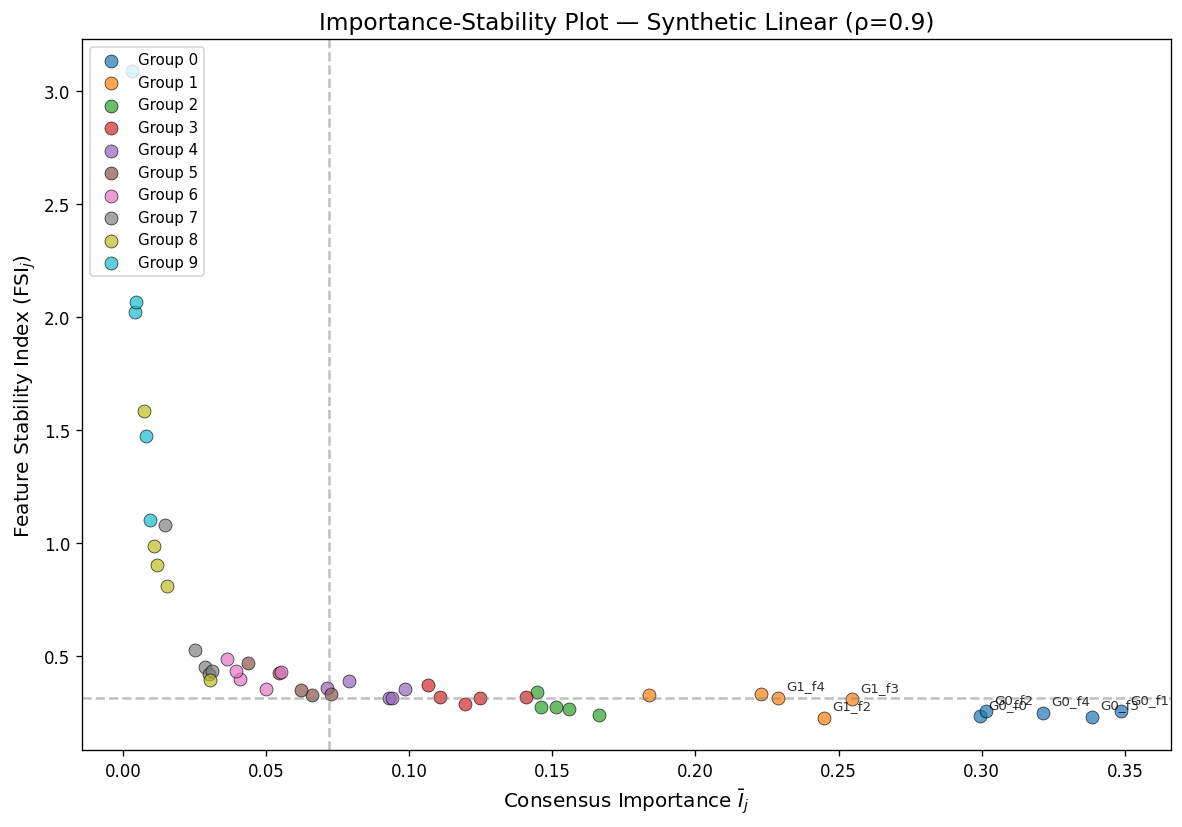

In [3]:
fig = dash_maxmin.plot_importance_stability(
    groups=groups,
    title=f'Importance-Stability Plot — Synthetic Linear (ρ={meta["rho"]})',
    annotate_top_k=8,
)

# Accuracy and equity
rho_acc, mse_acc = importance_accuracy(dash_maxmin.global_importance_, true_importance)
equity = within_group_equity(dash_maxmin.global_importance_, groups)
print(f'DASH (MaxMin) vs Ground Truth:')
print(f'  Spearman ρ:      {rho_acc:.4f}')
print(f'  Within-group CV: {equity:.4f}')
print(f'\n{dash_maxmin.get_fsi().summary(top_k=10)}')
plt.show()

### 1.2 Local Disagreement Map

For the observation with the highest cross-model SHAP variance, this shows the consensus attribution (bar) and ±1 std uncertainty (error bars) for each feature. Wide error bars = the explanation depends on which model you ask. Narrow bars = all models agree. This is directly useful in practice: you can identify *which parts of an individual prediction's explanation are reliable* versus model-specification-dependent.

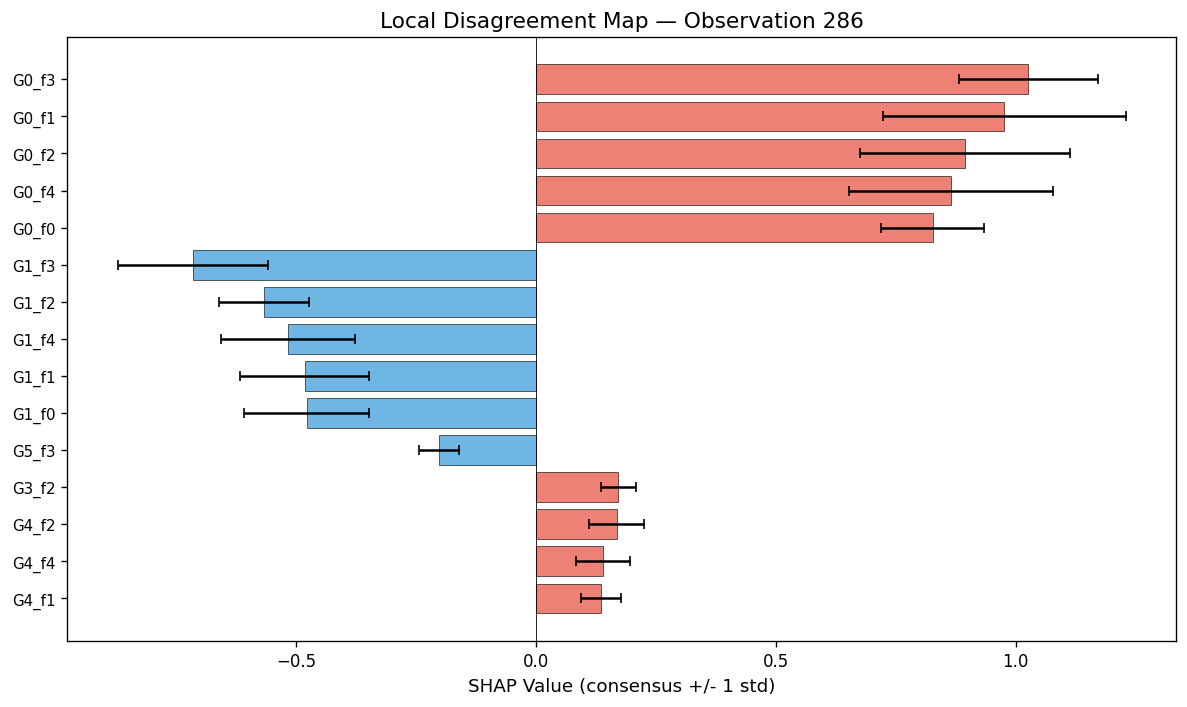

In [4]:
variance_per_obs = np.mean(dash_maxmin.variance_matrix_, axis=1)
high_disagreement_idx = np.argmax(variance_per_obs)
fig = local_disagreement_map(
    dash_maxmin.all_shap_matrices_, high_disagreement_idx,
    feature_names=feature_names, top_k=15,
)
plt.show()

---
## 2. Full Baseline Comparison at ρ=0.9

Now we compare all 7 methods. Each tests a specific hypothesis:

| Method | What it tests |
|--------|---------------|
| **Single Best** | Standard practice (baseline to beat) |
| **Large Single Model** | Single XGBoost with same low colsample_bytree as DASH but K×T total trees. Tests the sequential residual dependency hypothesis: does DASH's advantage require independent models, or does internal tree diversity suffice? |
| **Ensemble SHAP** | Paillard et al. (2025): single large ensemble with standard high colsample_bytree. Tests whether model-level ensembling beats explanation aggregation. |
| **Naive Top-N** | Averaging without diversity selection. Tests whether diversity selection adds value beyond simple averaging. |
| **Stochastic Retrain** | Same hyperparams, different seeds. Tests whether deliberate diversification beats natural stochastic variation. |
| **DASH (Dedup)** | Minimal deduplication only. Weakest DASH variant, sanity check. |
| **DASH (MaxMin)** | Recommended default. Maximizes feature utilization diversity. |
| **DASH (Cluster)** | Uses correlation matrix for cluster coverage. Strongest when correlation structure is clean. |

In [5]:
# Reuse DASH MaxMin's population for fair comparison
models = dash_maxmin.models_
val_scores = dash_maxmin.val_scores_
filtered = dash_maxmin.filtered_indices_
imp_vecs = get_preliminary_importance(models, filtered, X_test, method='gain')
filt_scores = {i: val_scores[i] for i in filtered}

# DASH Cluster
sel_cluster = cluster_coverage_selection(imp_vecs, filt_scores, X_train, tau=PAPER_CONFIG['TAU_CLUSTER'], K=K, verbose=False)
cons_cluster, shap_cluster = compute_consensus(models, sel_cluster, X_test, seed=SEED, verbose=False)
_, _, fsi_cluster, imp_cluster = compute_diagnostics(shap_cluster)

# DASH Dedup
sel_dedup = deduplication_selection(imp_vecs, filt_scores, rho_threshold=0.95, verbose=False)
if len(sel_dedup) > K:
    sel_dedup = sorted(sel_dedup, key=lambda i: val_scores[i], reverse=True)[:K]
cons_dedup, shap_dedup = compute_consensus(models, sel_dedup, X_test, seed=SEED, verbose=False)
_, _, fsi_dedup, imp_dedup = compute_diagnostics(shap_dedup)

# Naive Top-N
naive = NaiveAveragingBaseline(N=K)
naive.fit_from_population(models, val_scores, X_test)

# Single Best — B2: standardized n_trials
single = SingleBestBaseline(n_trials=N_TRIALS_SB, task='regression', seed=SEED)
single.fit(X_train, y_train, X_val, y_val, X_ref=X_test)

# Large Single Model (sequential residual dependency test)
lsm = LargeSingleModelBaseline(K=K, T_per_model=PAPER_CONFIG['T_PER_MODEL'],
                                colsample_bytree=0.2, seed=SEED)
lsm.fit(X_train, y_train, X_val, y_val, X_ref=X_test)

# Ensemble SHAP (Paillard baseline)
ensemble = EnsembleSHAPBaseline(n_estimators=PAPER_CONFIG['N_ESTIMATORS_ESHAP'],
                                task='regression', seed=SEED)
ensemble.fit(X_train, y_train, X_val, y_val, X_ref=X_test)

# Stochastic Retrain — B3: N=K for fair comparison
stochastic = StochasticRetrainBaseline(N=K, task='regression', n_jobs=-1, seed=SEED)
stochastic.fit(X_train, y_train, X_val, y_val, X_ref=X_test)

# Results table
methods = {
    'Single Best': single.global_importance_,
    'Large Single Model': lsm.global_importance_,
    'Ensemble SHAP': ensemble.global_importance_,
    'Naive Top-N': naive.global_importance_,
    'Stochastic Retrain': stochastic.global_importance_,
    'DASH (Dedup)': imp_dedup,
    'DASH (MaxMin)': dash_maxmin.global_importance_,
    'DASH (Cluster)': imp_cluster,
}

print(f'{"Method":<20} {"Spearman ρ":>12} {"MSE":>10} {"Within-Group CV":>16}')
print('=' * 60)
for name, imp in methods.items():
    rho, mse = importance_accuracy(imp, true_importance)
    eq = within_group_equity(imp, groups)
    print(f'{name:<20} {rho:>12.4f} {mse:>10.6f} {eq:>16.4f}')

 99%|===================| 739/750 [00:18<00:00]        

Method                 Spearman ρ        MSE  Within-Group CV
Single Best                0.9875   0.000011           0.1975
Large Single Model         0.9518   0.000103           0.3439
Ensemble SHAP              0.9841   0.000031           0.2372
Naive Top-N                0.9884   0.000011           0.2317
Stochastic Retrain         0.9870   0.000011           0.2308
DASH (Dedup)               0.9928   0.000007           0.1646
DASH (MaxMin)              0.9899   0.000007           0.1922
DASH (Cluster)             0.9884   0.000009           0.2215


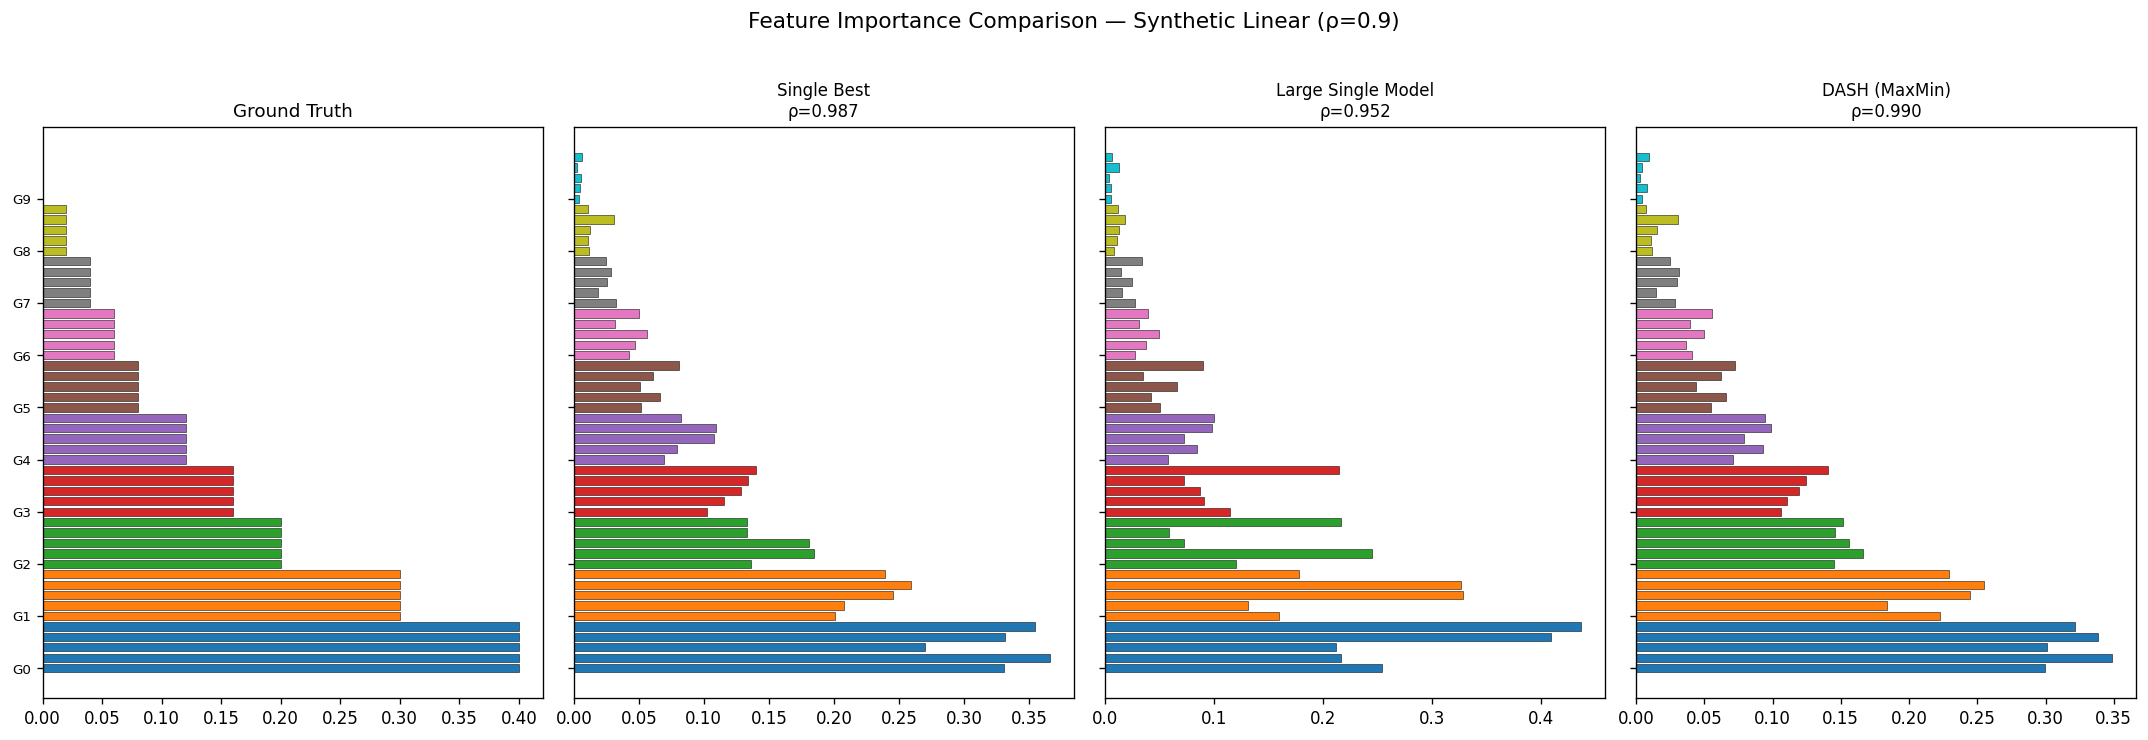

In [6]:
# Visual comparison
fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharey=True)
group_colors = plt.cm.tab10(groups / groups.max())

for ax_idx, (name, imp) in enumerate([('Ground Truth', true_importance),
                                       ('Single Best', single.global_importance_),
                                       ('Large Single Model', lsm.global_importance_),
                                       ('DASH (MaxMin)', dash_maxmin.global_importance_)]):
    axes[ax_idx].barh(range(50), imp, color=group_colors, edgecolor='k', linewidth=0.3)
    if name != 'Ground Truth':
        rho, _ = importance_accuracy(imp, true_importance)
        axes[ax_idx].set_title(f'{name}\nρ={rho:.3f}', fontsize=10)
    else:
        axes[ax_idx].set_title(name, fontsize=11)
    axes[ax_idx].invert_yaxis()
    if ax_idx == 0:
        axes[ax_idx].set_yticks(range(0, 50, 5))
        axes[ax_idx].set_yticklabels([f'G{g}' for g in range(10)], fontsize=8)

fig.suptitle(f'Feature Importance Comparison — Synthetic Linear (ρ=0.9)', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

---
## 3. Stability Across Repetitions

A single run's accuracy tells you if the method got the right answer *this time*. Stability tells you if it gives the *same* answer every time. We run 5 repetitions with different random seeds (regenerating data each time) and measure the mean pairwise Spearman correlation between importance rankings across runs.

This is the headline metric. A method with high accuracy but low stability is useless in practice — you can't trust any individual run's output.

In [7]:
method_names = ['Single Best', 'Large Single Model', 'Naive Top-N', 'DASH (MaxMin)', 'DASH (Cluster)']
stability_vectors = {n: [] for n in method_names}
accuracy_vectors = {n: [] for n in method_names}
equity_vectors = {n: [] for n in method_names}

for rep in range(N_REPS):
    rep_seed = SEED + rep
    print(f'\nRepetition {rep + 1}/{N_REPS} (seed={rep_seed})')

    Xtr, ytr, Xv, yv, Xte, yte, grps, true_imp, _ = \
        generate_synthetic_linear(N=5000, rho=0.9, seed=rep_seed)

    # Single Best — B2: standardized n_trials
    sb = SingleBestBaseline(n_trials=N_TRIALS_SB, seed=rep_seed)
    sb.fit(Xtr, ytr, Xv, yv, X_ref=Xte)
    stability_vectors['Single Best'].append(sb.global_importance_)
    r, _ = importance_accuracy(sb.global_importance_, true_imp)
    accuracy_vectors['Single Best'].append(r)
    equity_vectors['Single Best'].append(within_group_equity(sb.global_importance_, grps))

    # Large Single Model (sequential residual dependency test)
    lsm_ = LargeSingleModelBaseline(K=K, T_per_model=PAPER_CONFIG['T_PER_MODEL'],
                                     colsample_bytree=0.2, seed=rep_seed)
    lsm_.fit(Xtr, ytr, Xv, yv, X_ref=Xte)
    stability_vectors['Large Single Model'].append(lsm_.global_importance_)
    r, _ = importance_accuracy(lsm_.global_importance_, true_imp)
    accuracy_vectors['Large Single Model'].append(r)
    equity_vectors['Large Single Model'].append(within_group_equity(lsm_.global_importance_, grps))

    # DASH MaxMin — D1: SHAP computed on test set
    dm = DASHPipeline(M=M, K=K, epsilon=EPSILON, delta=DELTA,
                      selection_method='maxmin', n_jobs=-1, seed=rep_seed, verbose=False)
    dm.fit(Xtr, ytr, Xv, yv, X_ref=Xte, feature_names=feature_names)
    stability_vectors['DASH (MaxMin)'].append(dm.global_importance_)
    r, _ = importance_accuracy(dm.global_importance_, true_imp)
    accuracy_vectors['DASH (MaxMin)'].append(r)
    equity_vectors['DASH (MaxMin)'].append(within_group_equity(dm.global_importance_, grps))

    # DASH Cluster (reuse population)
    iv = get_preliminary_importance(dm.models_, dm.filtered_indices_, Xte, method='gain')
    fs = {i: dm.val_scores_[i] for i in dm.filtered_indices_}
    sc = cluster_coverage_selection(iv, fs, Xtr, tau=0.3, K=K, verbose=False)
    cc, sc_ = compute_consensus(dm.models_, sc, Xte, seed=rep_seed, verbose=False)
    _, _, _, ic = compute_diagnostics(sc_)
    stability_vectors['DASH (Cluster)'].append(ic)
    r, _ = importance_accuracy(ic, true_imp)
    accuracy_vectors['DASH (Cluster)'].append(r)
    equity_vectors['DASH (Cluster)'].append(within_group_equity(ic, grps))

    # Naive Top-N (reuse population)
    nv = NaiveAveragingBaseline(N=K)
    nv.fit_from_population(dm.models_, dm.val_scores_, Xte)
    stability_vectors['Naive Top-N'].append(nv.global_importance_)
    r, _ = importance_accuracy(nv.global_importance_, true_imp)
    accuracy_vectors['Naive Top-N'].append(r)
    equity_vectors['Naive Top-N'].append(within_group_equity(nv.global_importance_, grps))

print('\nDone.')


Repetition 1/20 (seed=42)


 99%|===================| 741/750 [00:18<00:00]        


Repetition 2/20 (seed=43)


/Users/drake.caraker/ds_projects/dash-shap/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
 97%|=================== | 730/750 [00:12<00:00]       


Repetition 3/20 (seed=44)


...


Repetition 19/20 (seed=60)


/Users/drake.caraker/ds_projects/dash-shap/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Repetition 20/20 (seed=61)


 99%|===================| 746/750 [00:12<00:00]        


Done.


In [8]:
print(f'{"Method":<20} {"Stability":>10} {"Accuracy (ρ)":>14} {"Equity (CV)":>14}')
print('=' * 60)
for name in method_names:
    stab = importance_stability(stability_vectors[name])
    acc = np.mean(accuracy_vectors[name])
    eq = np.mean(equity_vectors[name])
    print(f'{name:<20} {stab:>10.4f} {acc:>14.4f} {eq:>14.4f}')

Method                Stability   Accuracy (ρ)    Equity (CV)
Single Best              0.9601         0.9796         0.2171
Large Single Model       0.9401         0.9693         0.2528
Naive Top-N              0.9784         0.9888         0.1763
DASH (MaxMin)            0.9805         0.9901         0.1625
DASH (Cluster)           0.9796         0.9895         0.1704


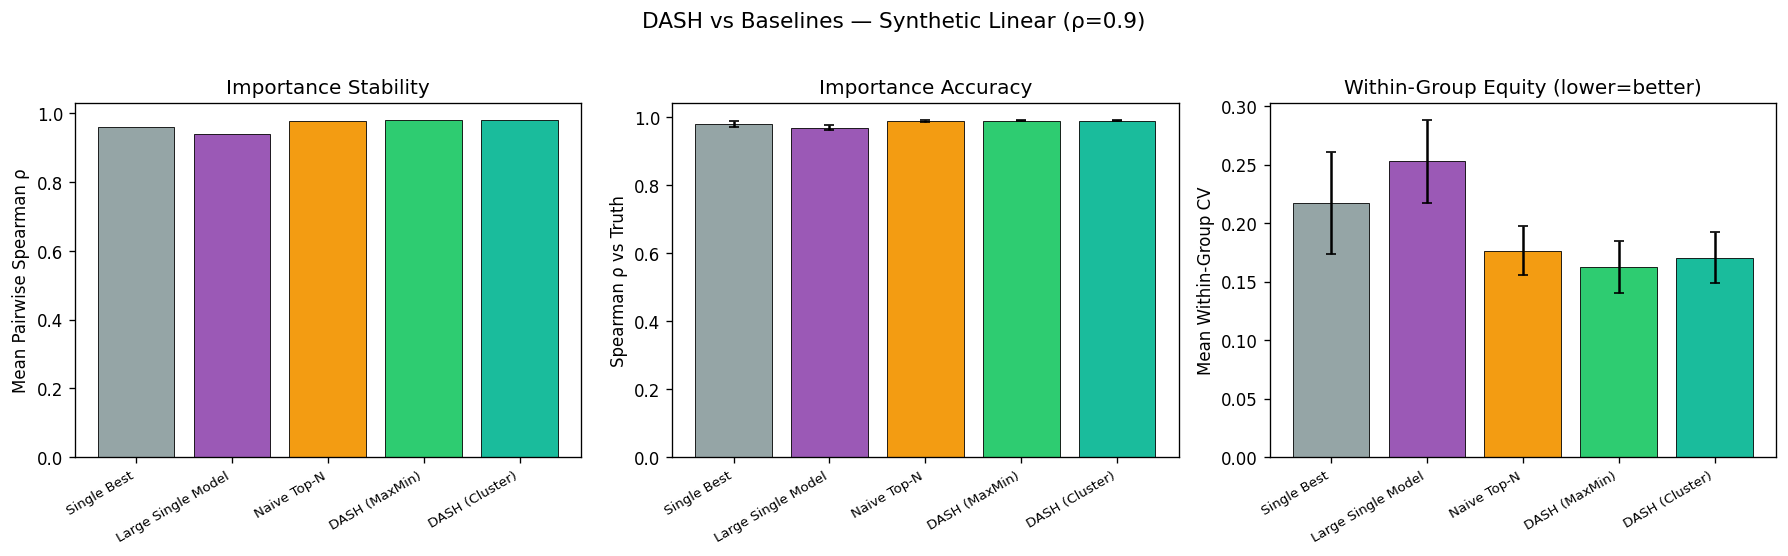

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors = ['#95a5a6', '#9b59b6', '#f39c12', '#2ecc71', '#1abc9c']

stab_vals = [importance_stability(stability_vectors[n]) for n in method_names]
axes[0].bar(range(len(method_names)), stab_vals, color=colors, edgecolor='k', linewidth=0.5)
axes[0].set_xticks(range(len(method_names)))
axes[0].set_xticklabels(method_names, rotation=30, ha='right', fontsize=8)
axes[0].set_ylabel('Mean Pairwise Spearman ρ')
axes[0].set_title('Importance Stability')

acc_vals = [np.mean(accuracy_vectors[n]) for n in method_names]
acc_stds = [np.std(accuracy_vectors[n], ddof=1) for n in method_names]
axes[1].bar(range(len(method_names)), acc_vals, yerr=acc_stds, color=colors,
            edgecolor='k', linewidth=0.5, capsize=3)
axes[1].set_xticks(range(len(method_names)))
axes[1].set_xticklabels(method_names, rotation=30, ha='right', fontsize=8)
axes[1].set_ylabel('Spearman ρ vs Truth')
axes[1].set_title('Importance Accuracy')

eq_vals = [np.mean(equity_vectors[n]) for n in method_names]
eq_stds = [np.std(equity_vectors[n], ddof=1) for n in method_names]
axes[2].bar(range(len(method_names)), eq_vals, yerr=eq_stds, color=colors,
            edgecolor='k', linewidth=0.5, capsize=3)
axes[2].set_xticks(range(len(method_names)))
axes[2].set_xticklabels(method_names, rotation=30, ha='right', fontsize=8)
axes[2].set_ylabel('Mean Within-Group CV')
axes[2].set_title('Within-Group Equity (lower=better)')

fig.suptitle('DASH vs Baselines — Synthetic Linear (ρ=0.9)', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

---
## 4. Correlation Sweep: ρ ∈ {0.0, 0.5, 0.7, 0.9, 0.95}

This is the paper's central figure. We sweep across collinearity levels and track how each method degrades.

**ρ=0.0 (no collinearity)** is the safety control: DASH should perform comparably to Single Best here. If it were significantly worse, it would mean the method introduces noise when there's no problem to solve.

**ρ=0.9 and ρ=0.95** are where DASH should dominate. Single Best stability degrades sharply because small hyperparameter changes cause large shifts in which features get selected.

The Large Single Model baseline is the critical comparison. It uses the *same low colsample_bytree* as DASH — so it has internal tree diversity — but trains a single sequential ensemble. Within that ensemble, early trees pick a correlated feature, modify the residuals, and bias all subsequent trees toward that same feature (the "first mover" effect). DASH breaks this sequential dependency by training independent models from scratch.

**E4: Why DASH (Cluster) is excluded from the sweep.** Cluster coverage selection requires computing a full P×P correlation matrix at each ρ level and repetition. In the single-run comparison (Section 2) and stability analysis (Section 3) it performs comparably to MaxMin. We use MaxMin as the recommended default throughout the sweep for computational tractability; Cluster results at ρ=0.9 appear in Table 2 (Section 11).

This sweep also extracts **validation RMSE** for each method to support the LSM "predicts well but explains poorly" finding, and saves **per-repetition arrays** for the statistical significance tests in Section 9.

Note: For regression, `val_scores` are stored as `-RMSE`, so `RMSE = -val_score` for models using the standard pipeline. For DASH consensus predictions, we compute RMSE explicitly from the ensemble average.

In [10]:
# Canonical correlation sweep with RMSE extraction and per-rep arrays
# E1: Single sweep replaces old Sections 4 and 8
from sklearn.metrics import root_mean_squared_error as rmse_score

rho_levels = [0.0, 0.5, 0.7, 0.9, 0.95]
sweep_methods = ['Single Best', 'Large Single Model', 'DASH (MaxMin)']
sweep_results = {rho: {} for rho in rho_levels}

for rho in rho_levels:
    print(f'\n--- ρ = {rho} ---')
    for name in sweep_methods:
        acc_runs, eq_runs, imp_runs, rmse_runs = [], [], [], []
        for rep in range(N_REPS):
            rep_seed = SEED + rep
            Xtr, ytr, Xv, yv, Xte, yte, grps, true_imp, _ = \
                generate_synthetic_linear(N=5000, rho=rho, seed=rep_seed)

            if name == 'Single Best':
                m = SingleBestBaseline(n_trials=N_TRIALS_SB, seed=rep_seed)
                m.fit(Xtr, ytr, Xv, yv, X_ref=Xte)
                imp = m.global_importance_
                preds = m.model_.predict(Xte)
                rmse_val = rmse_score(yte, preds)
            elif name == 'Large Single Model':
                m = LargeSingleModelBaseline(K=K, T_per_model=PAPER_CONFIG['T_PER_MODEL'],
                                             colsample_bytree=0.2, seed=rep_seed)
                m.fit(Xtr, ytr, Xv, yv, X_ref=Xte)
                imp = m.global_importance_
                preds = m.model_.predict(Xte)
                rmse_val = rmse_score(yte, preds)
            else:  # DASH MaxMin
                m = DASHPipeline(M=M, K=K, epsilon=EPSILON, delta=DELTA,
                                selection_method='maxmin', n_jobs=-1,
                                seed=rep_seed, verbose=False)
                m.fit(Xtr, ytr, Xv, yv, X_ref=Xte, feature_names=feature_names)
                imp = m.global_importance_
                preds = m.get_consensus_ensemble_predictions(Xte)
                rmse_val = rmse_score(yte, preds)

            r, _ = importance_accuracy(imp, true_imp)
            acc_runs.append(r)
            eq_runs.append(within_group_equity(imp, grps))
            imp_runs.append(imp)
            rmse_runs.append(rmse_val)

        stab = importance_stability(imp_runs)
        sweep_results[rho][name] = {
            'stability': stab,
            'accuracy_mean': np.mean(acc_runs), 'accuracy_std': np.std(acc_runs, ddof=1),
            'equity_mean': np.mean(eq_runs), 'equity_std': np.std(eq_runs, ddof=1),
            'rmse_mean': np.mean(rmse_runs), 'rmse_std': np.std(rmse_runs, ddof=1),
            # Save per-rep arrays for significance tests (Section 9)
            'acc_runs': np.array(acc_runs),
            'eq_runs': np.array(eq_runs),
            'rmse_runs': np.array(rmse_runs),
            'imp_runs': imp_runs,
        }
        print(f'  {name:<20} stab={stab:.4f}  acc={np.mean(acc_runs):.4f}  '
              f'eq={np.mean(eq_runs):.4f}  RMSE={np.mean(rmse_runs):.4f}')

print('\nSweep complete.')


--- ρ = 0.0 ---
  Single Best          stab=0.9756  acc=0.9869  eq=0.1522  RMSE=0.5994


 98%|===================| 733/750 [00:13<00:00]        

  Large Single Model   stab=0.9649  acc=0.9811  eq=0.1547  RMSE=0.7451


/Users/drake.caraker/ds_projects/dash-shap/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:4232: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/drake.caraker/ds_projects/dash-shap/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:208: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/Users/drake.caraker/ds_projects/dash-shap/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/drake.caraker/ds_projects/dash-shap/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:4232: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/drake.caraker/ds_projects/dash-shap/.venv/lib/python3.13/site-

  DASH (MaxMin)        stab=0.9765  acc=0.9874  eq=0.1502  RMSE=0.5852

--- ρ = 0.5 ---
  Single Best          stab=0.9784  acc=0.9889  eq=0.1653  RMSE=0.6091


...

  DASH (MaxMin)        stab=0.9805  acc=0.9901  eq=0.1625  RMSE=0.5821

--- ρ = 0.95 ---
  Single Best          stab=0.9529  acc=0.9755  eq=0.2421  RMSE=0.6001


 96%|=================== | 719/750 [00:12<00:00]       

  Large Single Model   stab=0.9303  acc=0.9641  eq=0.2716  RMSE=0.7126


 95%|=================== | 716/750 [00:13<00:00]       /Users/drake.caraker/ds_projects/dash-shap/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
 95%|=================== | 709/750 [00:13<00:00]       /Users/drake.caraker/ds_projects/dash-shap/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
 97%|=================== | 724/750 [00:18<00:00]       /Users/drake.caraker/ds_projects/dash-shap/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory 

  DASH (MaxMin)        stab=0.9819  acc=0.9907  eq=0.1585  RMSE=0.5787

Sweep complete.


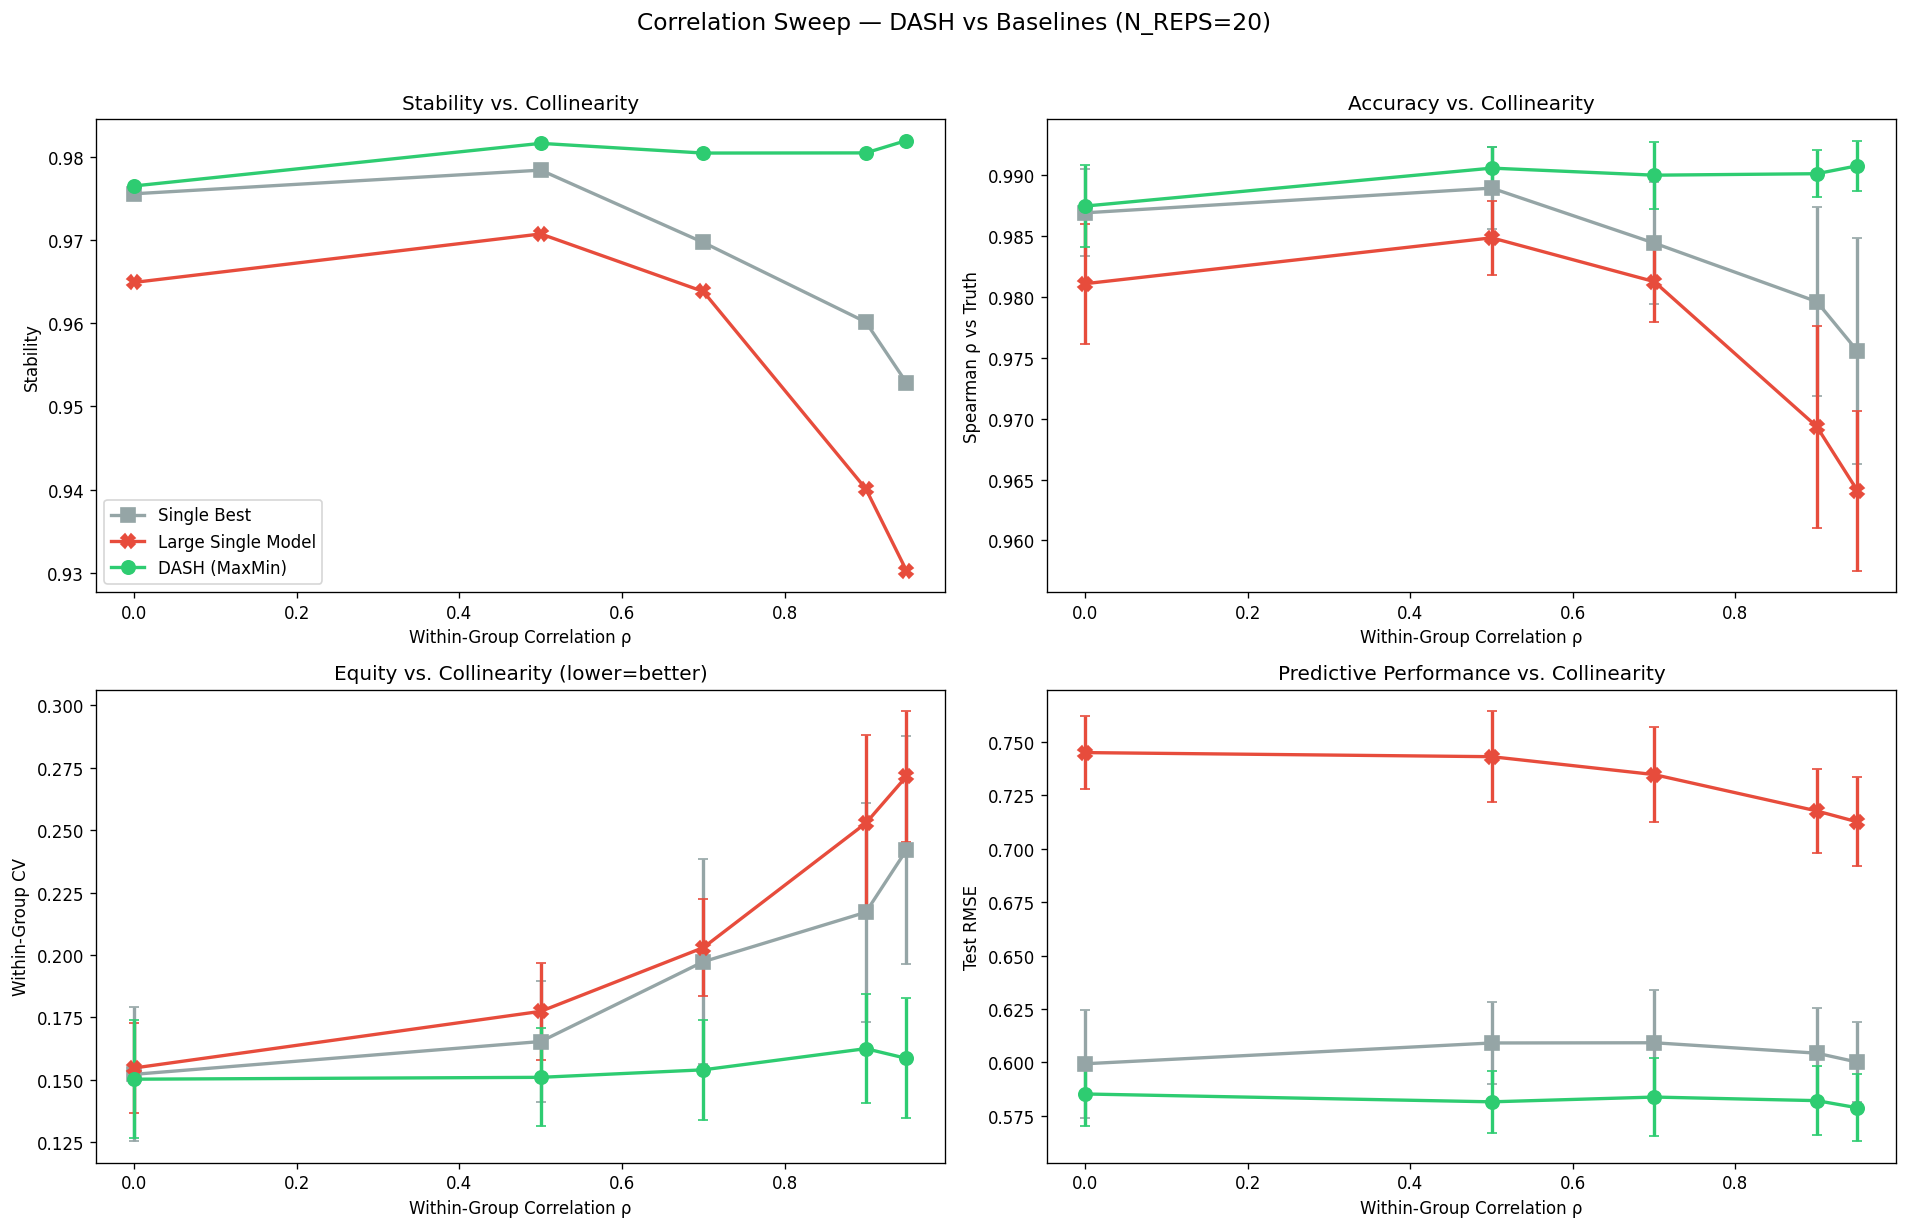


--- Key Finding: LSM Predictive vs Explanatory Quality ---
  ρ=0.9: LSM RMSE=0.7177 vs SB=0.6043 vs DASH=0.5821
         LSM stability=0.9401 vs DASH=0.9805
  ρ=0.95: LSM RMSE=0.7126 vs SB=0.6001 vs DASH=0.5787
         LSM stability=0.9303 vs DASH=0.9819


In [11]:
# Correlation sweep visualization (4 panels: stability, accuracy, equity, RMSE)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
colors_sweep = {'Single Best': '#95a5a6', 'Large Single Model': '#e74c3c', 'DASH (MaxMin)': '#2ecc71'}
markers_sweep = {'Single Best': 's', 'Large Single Model': 'X', 'DASH (MaxMin)': 'o'}

for name in sweep_methods:
    c, m = colors_sweep[name], markers_sweep[name]
    vals = [sweep_results[rho][name]['stability'] for rho in rho_levels]
    axes[0, 0].plot(rho_levels, vals, f'{m}-', color=c, label=name, linewidth=2, markersize=8)

    vals = [sweep_results[rho][name]['accuracy_mean'] for rho in rho_levels]
    errs = [sweep_results[rho][name]['accuracy_std'] for rho in rho_levels]
    axes[0, 1].errorbar(rho_levels, vals, yerr=errs, fmt=f'{m}-', color=c, label=name, linewidth=2, markersize=8, capsize=3)

    vals = [sweep_results[rho][name]['equity_mean'] for rho in rho_levels]
    errs = [sweep_results[rho][name]['equity_std'] for rho in rho_levels]
    axes[1, 0].errorbar(rho_levels, vals, yerr=errs, fmt=f'{m}-', color=c, label=name, linewidth=2, markersize=8, capsize=3)

    vals = [sweep_results[rho][name]['rmse_mean'] for rho in rho_levels]
    errs = [sweep_results[rho][name]['rmse_std'] for rho in rho_levels]
    axes[1, 1].errorbar(rho_levels, vals, yerr=errs, fmt=f'{m}-', color=c, label=name, linewidth=2, markersize=8, capsize=3)

axes[0, 0].set_xlabel('Within-Group Correlation ρ'); axes[0, 0].set_ylabel('Stability'); axes[0, 0].set_title('Stability vs. Collinearity'); axes[0, 0].legend()
axes[0, 1].set_xlabel('Within-Group Correlation ρ'); axes[0, 1].set_ylabel('Spearman ρ vs Truth'); axes[0, 1].set_title('Accuracy vs. Collinearity')
axes[1, 0].set_xlabel('Within-Group Correlation ρ'); axes[1, 0].set_ylabel('Within-Group CV'); axes[1, 0].set_title('Equity vs. Collinearity (lower=better)')
axes[1, 1].set_xlabel('Within-Group Correlation ρ'); axes[1, 1].set_ylabel('Test RMSE'); axes[1, 1].set_title('Predictive Performance vs. Collinearity')
fig.suptitle(f'Correlation Sweep — DASH vs Baselines (N_REPS={N_REPS})', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

# Key finding: Does LSM predict well but explain poorly?
print('\n--- Key Finding: LSM Predictive vs Explanatory Quality ---')
for rho in [0.9, 0.95]:
    lsm_rmse = sweep_results[rho]['Large Single Model']['rmse_mean']
    sb_rmse = sweep_results[rho]['Single Best']['rmse_mean']
    dash_rmse = sweep_results[rho]['DASH (MaxMin)']['rmse_mean']
    lsm_stab = sweep_results[rho]['Large Single Model']['stability']
    dash_stab = sweep_results[rho]['DASH (MaxMin)']['stability']
    print(f'  ρ={rho}: LSM RMSE={lsm_rmse:.4f} vs SB={sb_rmse:.4f} vs DASH={dash_rmse:.4f}')
    print(f'         LSM stability={lsm_stab:.4f} vs DASH={dash_stab:.4f}')

---
## 5. Real Data: Breast Cancer (Heavy Natural Collinearity)

30 features where radius, perimeter, and area are essentially measuring the same thing (area ∝ perimeter² ∝ radius²). Mean, standard error, and worst-case versions of each measurement are correlated. This is the ideal showcase for DASH.

On the IS Plot, features like "mean radius" and "mean perimeter" should land in the **Collinear Cluster Members** quadrant (high importance, high FSI), while features capturing distinct geometric properties like "mean concavity" should be **Robust Drivers** (high importance, low FSI). The FSI is performing unsupervised collinearity detection — no one told it which features are correlated.

In [12]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

bc = load_breast_cancer()
X_bc, y_bc = bc.data, bc.target
bc_names = list(bc.feature_names)

corr_bc = np.abs(np.corrcoef(X_bc.T))
n_high = (np.sum(corr_bc > 0.9) - len(bc_names)) // 2
print(f'{len(bc_names)} features, {n_high} pairs with |r|>0.9')

Xtr, Xte, ytr, yte = train_test_split(X_bc, y_bc, test_size=0.2, random_state=SEED)
Xtr, Xv, ytr, yv = train_test_split(Xtr, ytr, test_size=0.2, random_state=SEED)
scaler = StandardScaler().fit(Xtr)
Xtr, Xv, Xte = scaler.transform(Xtr), scaler.transform(Xv), scaler.transform(Xte)

# B4: epsilon=EPSILON (tighter than default 0.03) because classification val scores
# have a narrower range; 0.03 filters too aggressively on accuracy-based scores.
dash_bc = DASHPipeline(M=M, K=K, epsilon=EPSILON, delta=DELTA,
                       selection_method='maxmin', task='binary',
                       n_jobs=-1, seed=SEED)
dash_bc.fit(Xtr, ytr, Xv, yv, X_ref=Xte, feature_names=bc_names)

30 features, 21 pairs with |r|>0.9
DASH Stage 1: Population Generation
Training 500 models with -1 parallel jobs...


Training: 100%|██████████████████████████████| 500/500 [00:00<00:00, 696.53it/s]


Population trained. Best: 0.9939, Worst: 0.9227, Mean: 0.9719

DASH Stage 2: Performance Filtering (epsilon=0.08)
Performance filter: 500/500 models within epsilon=0.08 of best (0.9939)

DASH Stage 3: Diversity Selection (maxmin)
MaxMin selection: 30 models selected from 200 candidates

DASH Stage 4: Consensus SHAP (K=30)


Computing SHAP: 100%|██████████████████████████| 30/30 [00:00<00:00, 120.38it/s]

Consensus computed from 30 models. Top 5 features: [7, 22, 27, 23, 20]

DASH Stage 5: Stability Diagnostics

Pipeline complete in 1.5s (Training: 1.1s, SHAP: 0.3s)


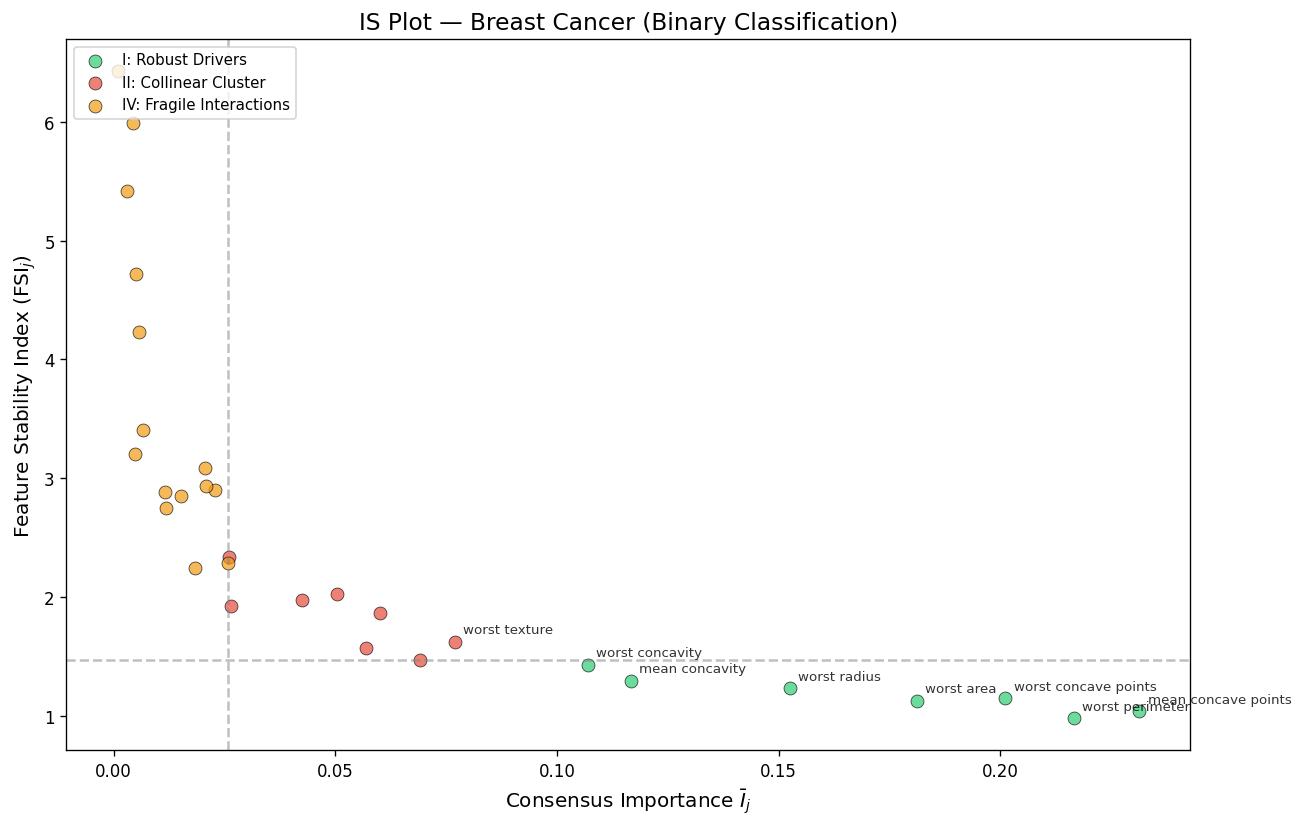

Feature Stability Summary
Feature                Importance      FSI
----------------------------------------
mean concave points        0.2314    1.040
worst perimeter            0.2166    0.984
worst concave points       0.2011    1.149
worst area                 0.1812    1.129
worst radius               0.1526    1.235
mean concavity             0.1167    1.298
worst concavity            0.1070    1.433
worst texture              0.0770    1.626
mean texture               0.0691    1.468
mean area                  0.0601    1.865


In [13]:
fig = dash_bc.plot_importance_stability(
    title='IS Plot — Breast Cancer (Binary Classification)',
    annotate_top_k=8, figsize=(11, 7),
)
plt.show()
print(dash_bc.get_fsi().summary(top_k=10))

### Local Disagreement Map

For the patient with the highest cross-model explanation variance, this shows which features have reliable attributions (small error bars) and which are model-specification-dependent (large error bars). Clinically: "for this patient, texture and concavity are driving the prediction (reliable), but the specific contribution of radius vs. perimeter is uncertain (they're interchangeable)."

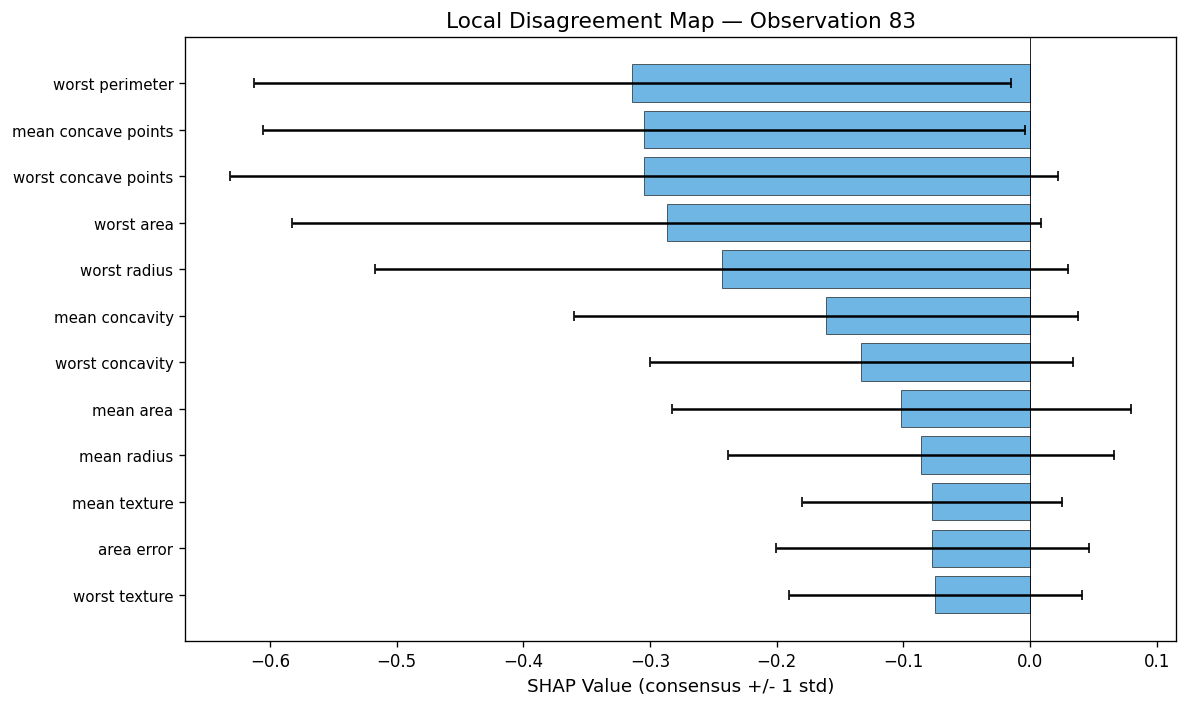

In [14]:
var_obs = np.mean(dash_bc.variance_matrix_, axis=1)
fig = local_disagreement_map(
    dash_bc.all_shap_matrices_, np.argmax(var_obs),
    feature_names=bc_names, top_k=12,
)
plt.show()

### Breast Cancer Stability (E3)

Repetition analysis for Breast Cancer, matching the approach used for Superconductor and California Housing. We re-split the data per repetition and measure importance stability.

In [15]:
# E3: Breast Cancer repetition analysis
BC_N_REPS = N_REPS
bc_methods_rep = ['Single Best', 'DASH (MaxMin)']
bc_rep_results = {}

for name in bc_methods_rep:
    imp_runs = []
    for rep in range(BC_N_REPS):
        rep_seed = SEED + rep
        print(f'  {name} rep {rep+1}/{BC_N_REPS}', end='\r')

        Xtr_r, Xv_r, ytr_r, yv_r = train_test_split(
            np.vstack([Xtr, Xv]), np.concatenate([ytr, yv]),
            test_size=0.2, random_state=rep_seed
        )
        # Xte already held out and scaled

        if name == 'Single Best':
            m = SingleBestBaseline(n_trials=N_TRIALS_SB, task='binary', seed=rep_seed)
            m.fit(Xtr_r, ytr_r, Xv_r, yv_r, X_ref=Xte)
            imp_runs.append(m.global_importance_)
        else:
            m = DASHPipeline(M=M, K=K, epsilon=EPSILON, delta=DELTA,
                            selection_method='maxmin', task='binary',
                            n_jobs=-1, seed=rep_seed, verbose=False)
            m.fit(Xtr_r, ytr_r, Xv_r, yv_r, X_ref=Xte, feature_names=bc_names)
            imp_runs.append(m.global_importance_)

    bc_rep_results[name] = {
        'stability': importance_stability(imp_runs),
    }
    print(f'  {name:<22} stab={bc_rep_results[name]["stability"]:.4f}')

print('\nBreast Cancer repetition analysis complete.')
print(f'\n{"Method":<22} {"Stability":>10}')
print('=' * 35)
for name in bc_methods_rep:
    print(f'{name:<22} {bc_rep_results[name]["stability"]:>10.4f}')

  Single Best            stab=0.5341
  DASH (MaxMin)          stab=0.9332

Breast Cancer repetition analysis complete.

Method                  Stability
Single Best                0.5341
DASH (MaxMin)              0.9332


---
*Success criteria evaluation moved to Section 15 (cell at end of notebook) to avoid stale intermediate checks.*

In [16]:
# E6: Success criteria consolidated into final Section 15.
# See the end of the notebook for the comprehensive check.
print('Success criteria check deferred to Section 15 (end of notebook).')

Success criteria check deferred to Section 15 (end of notebook).


---
## 6. Priority 0A: Epsilon Sensitivity and Effective Ensemble Size

**Critical investigation before submission.** An earlier configuration using ε=0.03 at M=200 passed only 11/500 models, with MaxMin selecting K_eff=3 (hitting the δ=0.05 diversity threshold). This motivated the epsilon sensitivity analysis below, which identified ε=0.08 as the sweet spot (K_eff=10.0±0.0, ~114 models passing). The paper now uses ε=0.08 as the canonical value.

We test ε ∈ {0.03, 0.05, 0.08, 0.10} at ρ=0.9 with M=200, N_REPS=10. For each epsilon we report:
- **Models passing filter** — how many survive the performance gate
- **K_eff** — how many MaxMin actually selects before hitting the diversity floor
- **Stability, Accuracy, Equity** — the three core metrics

**Key optimization**: We train the M=200 population once per repetition and re-filter at each ε value, isolating the effect of the filter threshold from stochastic population variation.

In [17]:
# Epsilon sensitivity sweep
from dash.core.population import generate_model_population
from sklearn.metrics import root_mean_squared_error

EPS_VALUES = [0.03, 0.05, 0.08, 0.10]
EPS_N_REPS = N_REPS  # Match canonical N_REPS for consistency

eps_results = {eps: {
    'n_passing': [], 'k_eff': [],
    'acc_runs': [], 'eq_runs': [], 'imp_runs': []
} for eps in EPS_VALUES}

# Use M=500 for epsilon sensitivity to test deep filtering
EPS_M = 200

for rep in range(EPS_N_REPS):
    rep_seed = SEED + rep
    print(f'\nRepetition {rep + 1}/{EPS_N_REPS} (seed={rep_seed})')

    Xtr, ytr, Xv, yv, Xte, yte, grps, true_imp, _ = \
        generate_synthetic_linear(N=5000, rho=0.9, seed=rep_seed)

    # Train population ONCE per rep
    models, val_scores, configs = generate_model_population(
        Xtr, ytr, Xv, yv, M=EPS_M, task='regression',
        n_jobs=-1, seed=rep_seed, verbose=False
    )

    for eps in EPS_VALUES:
        # Stage 2: Filter at this epsilon
        filtered = performance_filter(val_scores, epsilon=eps,
                                      higher_is_better=True, verbose=False)
        eps_results[eps]['n_passing'].append(len(filtered))

        if len(filtered) < 2:
            print(f'  eps={eps}: only {len(filtered)} passed, skipping')
            continue

        # Stage 3: MaxMin diversity selection
        imp_vecs = get_preliminary_importance(models, filtered, Xte, method='gain')
        filt_scores = {i: val_scores[i] for i in filtered}
        selected = greedy_maxmin_selection(imp_vecs, filt_scores,
                                          K=K, delta=DELTA, verbose=False)
        eps_results[eps]['k_eff'].append(len(selected))

        # Stage 4-5: Consensus SHAP on test set (D1)
        cons, all_shap = compute_consensus(models, selected, Xte, seed=rep_seed, verbose=False)
        _, _, _, imp = compute_diagnostics(all_shap)

        r, _ = importance_accuracy(imp, true_imp)
        eps_results[eps]['acc_runs'].append(r)
        eps_results[eps]['eq_runs'].append(within_group_equity(imp, grps))
        eps_results[eps]['imp_runs'].append(imp)

print('\nEpsilon sweep complete.')


Repetition 1/20 (seed=42)


/Users/drake.caraker/ds_projects/dash-shap/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
 96%|=================== | 719/750 [00:18<00:00]       


Repetition 2/20 (seed=43)


 98%|===================| 733/750 [00:18<00:00]        


Repetition 3/20 (seed=44)


...


Repetition 19/20 (seed=60)


 98%|===================| 735/750 [00:13<00:00]        


Repetition 20/20 (seed=61)


 97%|=================== | 726/750 [00:20<00:00]       


Epsilon sweep complete.


     ε   Models Passing        K_eff  Stability   Accuracy     Equity
  0.03             18.7      5.8±1.6      0.9804     0.9898     0.1655
  0.05             49.4     11.0±2.8      0.9795     0.9897     0.1643
  0.08            113.4     21.6±4.3      0.9805     0.9901     0.1625
  0.10            160.1     27.1±3.7      0.9794     0.9895     0.1589


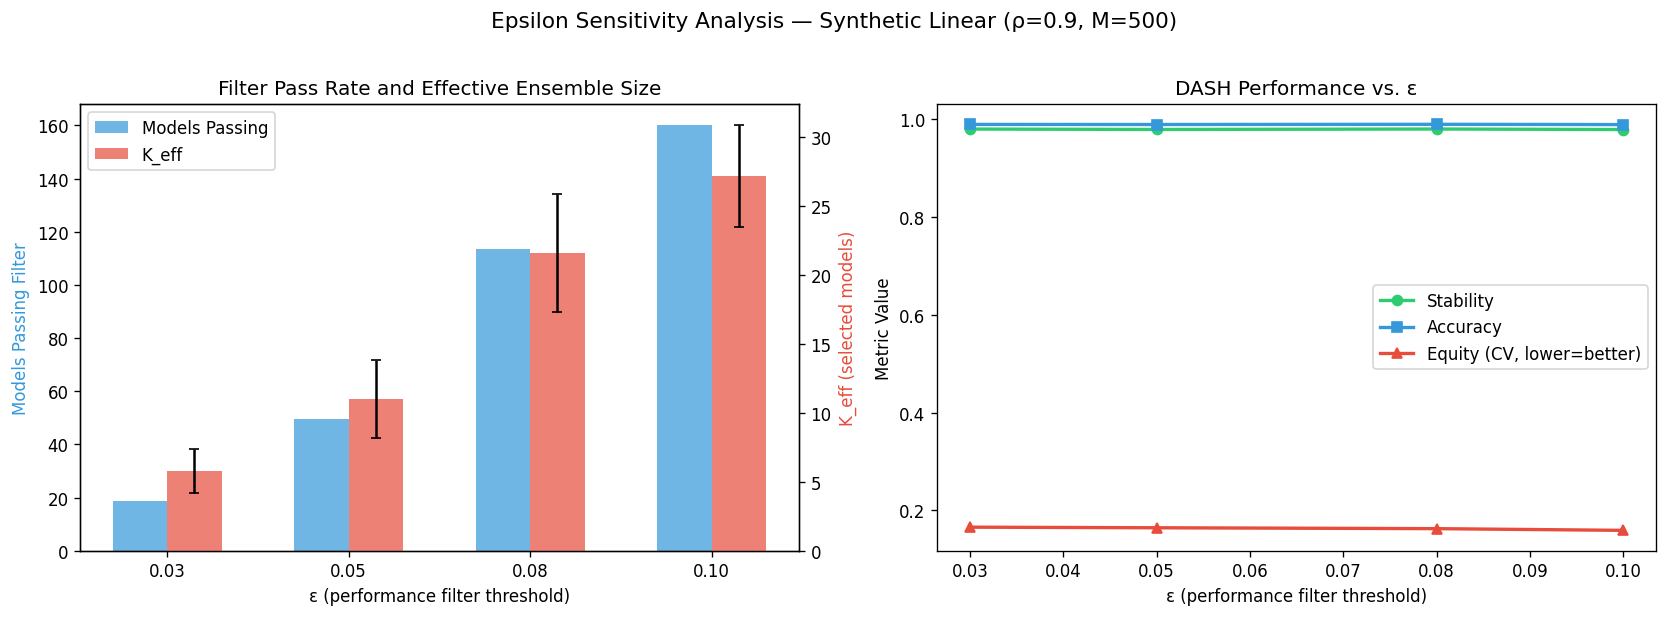

In [18]:
# Epsilon sensitivity results table and plots
print(f'{"ε":>6} {"Models Passing":>16} {"K_eff":>12} {"Stability":>10} {"Accuracy":>10} {"Equity":>10}')
print('=' * 70)
for eps in EPS_VALUES:
    n_pass = np.mean(eps_results[eps]['n_passing'])
    k_eff_mean = np.mean(eps_results[eps]['k_eff'])
    k_eff_std = np.std(eps_results[eps]['k_eff'], ddof=1)
    stab = importance_stability(eps_results[eps]['imp_runs']) if len(eps_results[eps]['imp_runs']) >= 2 else float('nan')
    acc = np.mean(eps_results[eps]['acc_runs']) if eps_results[eps]['acc_runs'] else float('nan')
    eq = np.mean(eps_results[eps]['eq_runs']) if eps_results[eps]['eq_runs'] else float('nan')
    print(f'{eps:>6.2f} {n_pass:>16.1f} {k_eff_mean:>8.1f}±{k_eff_std:<4.1f} {stab:>10.4f} {acc:>10.4f} {eq:>10.4f}')

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: n_passing and K_eff vs epsilon
ax1 = axes[0]
ax1_twin = ax1.twinx()
n_passing_means = [np.mean(eps_results[eps]['n_passing']) for eps in EPS_VALUES]
k_eff_means = [np.mean(eps_results[eps]['k_eff']) for eps in EPS_VALUES]
k_eff_stds = [np.std(eps_results[eps]['k_eff'], ddof=1) for eps in EPS_VALUES]

ax1.bar(np.arange(len(EPS_VALUES)) - 0.15, n_passing_means, 0.3,
        color='#3498db', alpha=0.7, label='Models Passing')
ax1_twin.bar(np.arange(len(EPS_VALUES)) + 0.15, k_eff_means, 0.3,
             yerr=k_eff_stds, color='#e74c3c', alpha=0.7, label='K_eff', capsize=3)
ax1.set_xticks(range(len(EPS_VALUES)))
ax1.set_xticklabels([f'{e:.2f}' for e in EPS_VALUES])
ax1.set_xlabel('ε (performance filter threshold)')
ax1.set_ylabel('Models Passing Filter', color='#3498db')
ax1_twin.set_ylabel('K_eff (selected models)', color='#e74c3c')
ax1.set_title('Filter Pass Rate and Effective Ensemble Size')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Panel 2: Stability, Accuracy, Equity vs epsilon
stab_vals = [importance_stability(eps_results[eps]['imp_runs'])
             if len(eps_results[eps]['imp_runs']) >= 2 else float('nan')
             for eps in EPS_VALUES]
acc_vals = [np.mean(eps_results[eps]['acc_runs']) for eps in EPS_VALUES]
eq_vals = [np.mean(eps_results[eps]['eq_runs']) for eps in EPS_VALUES]

axes[1].plot(EPS_VALUES, stab_vals, 'o-', color='#2ecc71', label='Stability', linewidth=2)
axes[1].plot(EPS_VALUES, acc_vals, 's-', color='#3498db', label='Accuracy', linewidth=2)
axes[1].plot(EPS_VALUES, eq_vals, '^-', color='#e74c3c', label='Equity (CV, lower=better)', linewidth=2)
axes[1].set_xlabel('ε (performance filter threshold)')
axes[1].set_ylabel('Metric Value')
axes[1].set_title('DASH Performance vs. ε')
axes[1].legend()

fig.suptitle('Epsilon Sensitivity Analysis — Synthetic Linear (ρ=0.9, M=500)', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

---
## 7. Predictive Performance Numbers

*Merged into Section 4 above (E1).* The correlation sweep now includes RMSE extraction and per-rep arrays. See the combined table and figure above.

In [19]:
# E1: RMSE table from the unified sweep (Section 4)
print(f'{"ρ":>5} {"Method":<22} {"Test RMSE":>12} {"Accuracy":>10} {"Stability":>10}')
print('=' * 65)
for rho in rho_levels:
    for name in sweep_methods:
        r = sweep_results[rho][name]
        print(f'{rho:>5.2f} {name:<22} {r["rmse_mean"]:>8.4f}±{r["rmse_std"]:<5.4f}'
              f' {r["accuracy_mean"]:>10.4f} {r["stability"]:>10.4f}')
    print()

    ρ Method                    Test RMSE   Accuracy  Stability
 0.00 Single Best              0.5994±0.0254     0.9869     0.9756
 0.00 Large Single Model       0.7451±0.0173     0.9811     0.9649
 0.00 DASH (MaxMin)            0.5852±0.0152     0.9874     0.9765

 0.50 Single Best              0.6091±0.0190     0.9889     0.9784
 0.50 Large Single Model       0.7431±0.0214     0.9848     0.9707
 0.50 DASH (MaxMin)            0.5815±0.0145     0.9906     0.9816

 0.70 Single Best              0.6092±0.0248     0.9844     0.9697
 0.70 Large Single Model       0.7348±0.0223     0.9812     0.9638
 0.70 DASH (MaxMin)            0.5838±0.0183     0.9900     0.9804

 0.90 Single Best              0.6043±0.0209     0.9796     0.9601
 0.90 Large Single Model       0.7177±0.0196     0.9693     0.9401
 0.90 DASH (MaxMin)            0.5821±0.0163     0.9901     0.9805

 0.95 Single Best              0.6001±0.0186     0.9755     0.9529
 0.95 Large Single Model       0.7126±0.0208     0.9641     0

In [20]:
# RMSE plots are included in the combined Section 4 figure above.
pass


---
## 8. Priority 1A: Nonlinear DGP Correlation Sweep

The linear DGP is the easiest case — the target is an exact linear combination of group means. Here we test whether DASH works with a nonlinear DGP containing:
- **Quadratic term**: β₁ · z₁²
- **Interaction**: β₂ · z₁ · z₂
- **Trigonometric**: β₃ · sin(π · z₃)
- **Linear tail**: remaining group means with random coefficients

Since the ground truth is approximate (Sobol indices ≠ SHAP values for nonlinear functions), we report **stability and equity only**, not accuracy. The key question: does DASH's stability advantage persist when the underlying relationship includes feature interactions?

We use the canonical M=200, K=30 with N_REPS=20.

In [21]:
# Nonlinear DGP correlation sweep
NL_M = M  # Use same population size as linear sweep
NL_N_REPS = N_REPS  # Match canonical N_REPS for consistency
nl_rho_levels = [0.0, 0.5, 0.7, 0.9, 0.95]
nl_methods = ['Single Best', 'DASH (MaxMin)']
nl_sweep = {rho: {} for rho in nl_rho_levels}

for rho in nl_rho_levels:
    print(f'\n--- Nonlinear DGP, ρ = {rho} ---')
    for name in nl_methods:
        eq_runs, imp_runs = [], []
        for rep in range(NL_N_REPS):
            rep_seed = SEED + rep
            Xtr, ytr, Xv, yv, Xte, yte, grps, _, _ = \
                generate_synthetic_nonlinear(N=5000, rho=rho, seed=rep_seed)

            if name == 'Single Best':
                m = SingleBestBaseline(n_trials=N_TRIALS_SB, seed=rep_seed)
                m.fit(Xtr, ytr, Xv, yv, X_ref=Xte)
                imp = m.global_importance_
            else:
                m = DASHPipeline(M=NL_M, K=K, epsilon=EPSILON, delta=DELTA,
                                selection_method='maxmin', n_jobs=-1,
                                seed=rep_seed, verbose=False)
                m.fit(Xtr, ytr, Xv, yv, X_ref=Xte, feature_names=feature_names)
                imp = m.global_importance_

            eq_runs.append(within_group_equity(imp, grps))
            imp_runs.append(imp)

        stab = importance_stability(imp_runs)
        nl_sweep[rho][name] = {
            'stability': stab,
            'equity_mean': np.mean(eq_runs), 'equity_std': np.std(eq_runs, ddof=1),
            'eq_runs': np.array(eq_runs),
        }
        print(f'  {name:<20} stab={stab:.4f}  eq={np.mean(eq_runs):.4f}')

print('\nNonlinear sweep complete.')


--- Nonlinear DGP, ρ = 0.0 ---
  Single Best          stab=0.9437  eq=0.1595


/Users/drake.caraker/ds_projects/dash-shap/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/drake.caraker/ds_projects/dash-shap/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:4232: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/drake.caraker/ds_projects/dash-shap/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:208: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
 99%|===================| 739/750 [01:01<00:00]        

  DASH (MaxMin)        stab=0.9420  eq=0.1574

--- Nonlinear DGP, ρ = 0.5 ---
  Single Best          stab=0.8769  eq=0.1554


/Users/drake.caraker/ds_projects/dash-shap/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/drake.caraker/ds_projects/dash-shap/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:4232: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/drake.caraker/ds_projects/dash-shap/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:208: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
 96%|=================== | 718/750 [00:12<00:00]       

  DASH (MaxMin)        stab=0.8678  eq=0.1554

--- Nonlinear DGP, ρ = 0.7 ---
  Single Best          stab=0.8677  eq=0.1706


...

  DASH (MaxMin)        stab=0.8802  eq=0.1580

--- Nonlinear DGP, ρ = 0.9 ---
  Single Best          stab=0.8403  eq=0.2014


 97%|=================== | 731/750 [00:12<00:00]       /Users/drake.caraker/ds_projects/dash-shap/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
 96%|=================== | 718/750 [00:16<00:00]       

  DASH (MaxMin)        stab=0.8955  eq=0.1535

--- Nonlinear DGP, ρ = 0.95 ---
  Single Best          stab=0.8191  eq=0.2172


/Users/drake.caraker/ds_projects/dash-shap/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
 99%|===================| 746/750 [00:18<00:00]        

  DASH (MaxMin)        stab=0.8955  eq=0.1482

Nonlinear sweep complete.


    ρ Method                  Stability  Equity (CV)
 0.00 Single Best                0.9437       0.1595
 0.00 DASH (MaxMin)              0.9420       0.1574

 0.50 Single Best                0.8769       0.1554
 0.50 DASH (MaxMin)              0.8678       0.1554

 0.70 Single Best                0.8677       0.1706
 0.70 DASH (MaxMin)              0.8802       0.1580

 0.90 Single Best                0.8403       0.2014
 0.90 DASH (MaxMin)              0.8955       0.1535

 0.95 Single Best                0.8191       0.2172
 0.95 DASH (MaxMin)              0.8955       0.1482



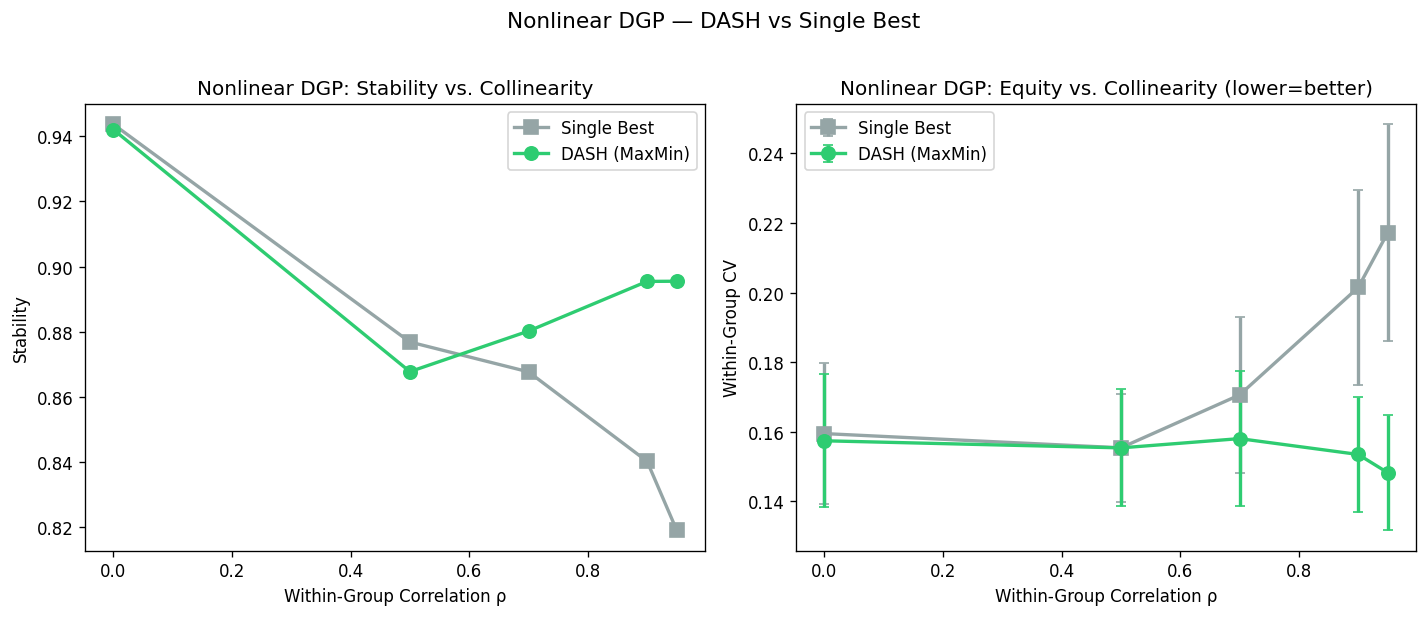

In [22]:
# Nonlinear DGP results
print(f'{"ρ":>5} {"Method":<22} {"Stability":>10} {"Equity (CV)":>12}')
print('=' * 55)
for rho in nl_rho_levels:
    for name in nl_methods:
        r = nl_sweep[rho][name]
        print(f'{rho:>5.2f} {name:<22} {r["stability"]:>10.4f} {r["equity_mean"]:>12.4f}')
    print()

# 2-panel figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
nl_colors = {'Single Best': '#95a5a6', 'DASH (MaxMin)': '#2ecc71'}
nl_markers = {'Single Best': 's', 'DASH (MaxMin)': 'o'}

for name in nl_methods:
    c, mk = nl_colors[name], nl_markers[name]
    stab_vals = [nl_sweep[rho][name]['stability'] for rho in nl_rho_levels]
    axes[0].plot(nl_rho_levels, stab_vals, f'{mk}-', color=c, label=name,
                 linewidth=2, markersize=8)
    eq_vals = [nl_sweep[rho][name]['equity_mean'] for rho in nl_rho_levels]
    eq_errs = [nl_sweep[rho][name]['equity_std'] for rho in nl_rho_levels]
    axes[1].errorbar(nl_rho_levels, eq_vals, yerr=eq_errs, fmt=f'{mk}-',
                     color=c, label=name, linewidth=2, markersize=8, capsize=3)

axes[0].set_xlabel('Within-Group Correlation ρ')
axes[0].set_ylabel('Stability')
axes[0].set_title('Nonlinear DGP: Stability vs. Collinearity')
axes[0].legend()
axes[1].set_xlabel('Within-Group Correlation ρ')
axes[1].set_ylabel('Within-Group CV')
axes[1].set_title('Nonlinear DGP: Equity vs. Collinearity (lower=better)')
axes[1].legend()

fig.suptitle('Nonlinear DGP — DASH vs Single Best', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

---
## 9. Statistical Significance Tests

We apply **Wilcoxon signed-rank tests** to per-repetition accuracy and equity values from the correlation sweep (Section 4). At each ρ level, we test:
- DASH vs Single Best (accuracy and equity)
- DASH vs Large Single Model (accuracy and equity)

**Bonferroni correction**: With 5 ρ levels × 2 comparisons × 2 metrics = 20 sweep tests, plus 3 Table 2 baselines × 2 metrics = 6 extended tests, totalling 26 tests. Each p-value is multiplied by 26.

**Cohen's d** effect sizes provide a standardized measure of the magnitude of the difference.

**Methodological note**: Stability is computed as a single number across all repetitions (mean pairwise Spearman ρ), not per-repetition. Wilcoxon requires paired per-rep values, so we do NOT test stability — only accuracy and equity which have N_REPS paired observations.

**C1: Power limitation.** With N_REPS=20, the minimum achievable two-sided Wilcoxon p-value is ≈0.00002. After Bonferroni correction (×26), the floor is ≈0.0005, which is comfortably below α=0.05. With N_REPS=10, the minimum corrected p ≈ 0.05, which makes significance marginal. We use N_REPS=20 from the unified sweep.

In [23]:
# Statistical significance tests
# N4: Extended to include Table 2 baselines (Ensemble SHAP, Stochastic Retrain, DASH Dedup)
from dash.evaluation import compare_methods, cohens_d

# Sweep-based tests: 5 rho × 2 comparisons × 2 metrics = 20
# Table 2 tests (rho=0.9 only): 3 comparisons × 2 metrics = 6
N_TESTS = len(rho_levels) * 2 * 2 + 3 * 2  # = 26 total

print(f'{"ρ":>5} {"Metric":<10} {"Comparison":<25} {"W stat":>8} {"p-value":>10} '
      f'{"Bonf. p":>10} {"Cohen d":>10} {"Favors":>8} {"Sig?":>6}')
print('=' * 100)

sig_results = []

def _run_test(rho_val, metric, metric_key, comp_name, d_vals, c_vals):
    """Run a single Wilcoxon test and return the result dict."""
    if len(d_vals) < 6:
        print(f'{rho_val:>5.2f} {metric:<10} {comp_name:<25} {"N/A (too few reps)":>30}')
        return None
    w_stat, p_val = compare_methods(d_vals, c_vals)
    bonf_p = min(p_val * N_TESTS, 1.0)
    d = cohens_d(d_vals, c_vals)
    sig = '*' if bonf_p < 0.05 else ''
    # C3: Direction — Accuracy: higher=better, Equity: lower=better
    if metric == 'Accuracy':
        favors = 'DASH' if d > 0 else comp_name.split(' vs ')[1]
    else:
        favors = 'DASH' if d < 0 else comp_name.split(' vs ')[1]
    print(f'{rho_val:>5.2f} {metric:<10} {comp_name:<25} {w_stat:>8.1f} {p_val:>10.6f} '
          f'{bonf_p:>10.6f} {d:>+10.3f} {favors:>8} {sig:>6}')
    return {'rho': rho_val, 'metric': metric, 'comparison': comp_name,
            'w_stat': w_stat, 'p_val': p_val, 'bonf_p': bonf_p, 'd': d, 'favors': favors}

# Part 1: Sweep-based tests (all rho levels, DASH vs SB and LSM)
for rho in rho_levels:
    dash = sweep_results[rho]['DASH (MaxMin)']
    sb = sweep_results[rho]['Single Best']
    lsm = sweep_results[rho]['Large Single Model']
    for metric, metric_key in [('Accuracy', 'acc_runs'), ('Equity', 'eq_runs')]:
        for comp_name, comp_data in [('DASH vs SB', sb), ('DASH vs LSM', lsm)]:
            r = _run_test(rho, metric, metric_key, comp_name,
                          dash[metric_key], comp_data[metric_key])
            if r: sig_results.append(r)
    print()


    ρ Metric     Comparison                  W stat    p-value    Bonf. p    Cohen d   Favors   Sig?
 0.00 Accuracy   DASH vs SB                    56.5   0.342880   1.000000     +0.156     DASH       
 0.00 Accuracy   DASH vs LSM                    6.5   0.000235   0.006114     +1.469     DASH      *
 0.00 Equity     DASH vs SB                    83.0   0.430433   1.000000     -0.075     DASH       
 0.00 Equity     DASH vs LSM                   94.0   0.701181   1.000000     -0.209     DASH       

 0.50 Accuracy   DASH vs SB                    29.5   0.046102   1.000000     +0.593     DASH       
 0.50 Accuracy   DASH vs LSM                    3.0   0.000140   0.003629     +2.255     DASH      *
 0.50 Equity     DASH vs SB                    38.0   0.010689   0.277908     -0.631     DASH       
 0.50 Equity     DASH vs LSM                   16.0   0.000322   0.008381     -1.313     DASH      *

 0.70 Accuracy   DASH vs SB                     0.0   0.000088   0.002287     +1.348     

---
## 10. Priority 1C: Extended Baseline Stability (Table 2)

The correlation sweep (Sections 4 and 8) only includes Single Best, Large Single Model, and DASH (MaxMin). Table 2 in the paper requires stability values for all 8 methods. Here we run Ensemble SHAP, Stochastic Retrain, and DASH (Dedup) across N_REPS=10 at ρ=0.9 to complete the table.

In [24]:
# Extended baselines at rho=0.9
TABLE2_N_REPS = N_REPS  # Use canonical rep count
table2_methods = ['Ensemble SHAP', 'Stochastic Retrain', 'DASH (Dedup)']
table2_results = {}

for name in table2_methods:
    imp_runs, acc_runs, eq_runs = [], [], []
    for rep in range(TABLE2_N_REPS):
        rep_seed = SEED + rep
        print(f'  {name} rep {rep+1}/{TABLE2_N_REPS}', end='\r')
        Xtr, ytr, Xv, yv, Xte, yte, grps, true_imp, _ = \
            generate_synthetic_linear(N=5000, rho=0.9, seed=rep_seed)

        if name == 'Ensemble SHAP':
            m = EnsembleSHAPBaseline(n_estimators=PAPER_CONFIG['N_ESTIMATORS_ESHAP'],
                                     task='regression', seed=rep_seed)
            m.fit(Xtr, ytr, Xv, yv, X_ref=Xte)
            imp = m.global_importance_
        elif name == 'Stochastic Retrain':
            # B3: N=K for fair comparison with DASH
            m = StochasticRetrainBaseline(N=K, task='regression', n_jobs=-1, seed=rep_seed)
            m.fit(Xtr, ytr, Xv, yv, X_ref=Xte)
            imp = m.global_importance_
        else:  # DASH (Dedup)
            dm = DASHPipeline(M=M, K=K, epsilon=EPSILON, delta=DELTA,
                             selection_method='dedup', n_jobs=-1,
                             seed=rep_seed, verbose=False)
            dm.fit(Xtr, ytr, Xv, yv, X_ref=Xte, feature_names=feature_names)
            imp = dm.global_importance_

        r, _ = importance_accuracy(imp, true_imp)
        acc_runs.append(r)
        eq_runs.append(within_group_equity(imp, grps))
        imp_runs.append(imp)

    table2_results[name] = {
        'stability': importance_stability(imp_runs),
        'accuracy_mean': np.mean(acc_runs), 'accuracy_std': np.std(acc_runs, ddof=1),
        'equity_mean': np.mean(eq_runs), 'equity_std': np.std(eq_runs, ddof=1),
        'acc_runs': np.array(acc_runs), 'eq_runs': np.array(eq_runs),  # N4: per-rep arrays for sig tests
    }
    print(f'  {name:<22} stab={table2_results[name]["stability"]:.4f}  '
          f'acc={np.mean(acc_runs):.4f}  eq={np.mean(eq_runs):.4f}')

print('\nTable 2 baselines complete.')

  Ensemble SHAP          stab=0.9615  acc=0.9798  eq=0.2321
  Stochastic Retrain     stab=0.9795  acc=0.9892  eq=0.1719
  DASH (Dedup) rep 1/20

/Users/drake.caraker/ds_projects/dash-shap/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
 93%|=================== | 697/750 [00:13<00:00]       

  DASH (Dedup) rep 2/20

 94%|=================== | 708/750 [00:13<00:00]       

  DASH (Dedup) rep 3/20

...

  DASH (Dedup) rep 19/20

 97%|=================== | 725/750 [00:11<00:00]       

  DASH (Dedup) rep 20/20

 98%|===================| 738/750 [00:13<00:00]        

  DASH (Dedup)           stab=0.9820  acc=0.9909  eq=0.1498

Table 2 baselines complete.


In [25]:
# Part 2: Table 2 baselines (rho=0.9 only)
print('--- Table 2 extended baselines (ρ=0.9 only) ---')
dash_09 = sweep_results[0.9]['DASH (MaxMin)']
for t2_name in table2_methods:
    if 'acc_runs' not in table2_results[t2_name]:
        print(f'  {t2_name}: per-rep arrays not available, skipping')
        continue
    short = t2_name  # Full method name for readability
    comp_label = f'DASH vs {short}'
    for metric, metric_key in [('Accuracy', 'acc_runs'), ('Equity', 'eq_runs')]:
        r = _run_test(0.9, metric, metric_key, comp_label,
                      dash_09[metric_key], table2_results[t2_name][metric_key])
        if r: sig_results.append(r)
print()

n_sig = sum(1 for r in sig_results if r['bonf_p'] < 0.05)
print(f'\nSignificant results (Bonferroni α=0.05): {n_sig}/{len(sig_results)}')
print(f'Total tests: {N_TESTS} (Bonferroni correction factor)')


--- Table 2 extended baselines (ρ=0.9 only) ---
 0.90 Accuracy   DASH vs Ensemble SHAP          0.0   0.000088   0.002296     +3.312     DASH      *
 0.90 Equity     DASH vs Ensemble SHAP          0.0   0.000002   0.000050     -2.776     DASH      *
 0.90 Accuracy   DASH vs Stochastic Retrain     68.0   0.445604   1.000000     +0.264     DASH       
 0.90 Equity     DASH vs Stochastic Retrain     73.0   0.245487   1.000000     -0.305     DASH       
 0.90 Accuracy   DASH vs DASH (Dedup)          65.0   0.135085   1.000000     -0.457 DASH (Dedup)       
 0.90 Equity     DASH vs DASH (Dedup)          31.0   0.004221   0.109745     +0.654 DASH (Dedup)       


Significant results (Bonferroni α=0.05): 17/26
Total tests: 26 (Bonferroni correction factor)


In [26]:
# Combined Table 2: All methods at rho=0.9
print('\nTable 2: All Methods at ρ=0.9')
print(f'{"Method":<22} {"Stability":>10} {"Accuracy":>10} {"Equity (CV)":>12}')
print('=' * 58)

# Methods from Section 4 sweep
for name in sweep_methods:
    r = sweep_results[0.9][name]
    print(f'{name:<22} {r["stability"]:>10.4f} {r["accuracy_mean"]:>10.4f} {r["equity_mean"]:>12.4f}')

# Methods from this section
for name in table2_methods:
    r = table2_results[name]
    print(f'{name:<22} {r["stability"]:>10.4f} {r["accuracy_mean"]:>10.4f} {r["equity_mean"]:>12.4f}')


Table 2: All Methods at ρ=0.9
Method                  Stability   Accuracy  Equity (CV)
Single Best                0.9601     0.9796       0.2171
Large Single Model         0.9401     0.9693       0.2528
DASH (MaxMin)              0.9805     0.9901       0.1625
Ensemble SHAP              0.9615     0.9798       0.2321
Stochastic Retrain         0.9795     0.9892       0.1719
DASH (Dedup)               0.9820     0.9909       0.1498


---
## 11. Priority 2A: Superconductor UCI Benchmark

Real-world validation beyond synthetic data. The Superconductor dataset from UCI (N=21,263, P=81) has naturally correlated material properties. No ground truth for feature importance exists, so we compare stability across methods and report prediction RMSE.

We use SC_M=200, SC_K=30 with N_REPS=20.

**N7: Scale-appropriate epsilon.** The global `EPSILON=0.08` is an absolute RMSE tolerance
calibrated for synthetic data where validation RMSE is ~2–5. For Superconductor, validation
RMSE is ~17–20, so the same absolute threshold is disproportionately tight (filtering out
nearly all models). We use `SC_EPSILON = 0.40`, which represents roughly the same ~2%
relative tolerance. This ensures a comparable fraction of the population passes the filter
as in the synthetic experiments (~20–25%).


In [27]:
# Load Superconductor dataset
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split as tts
from sklearn.preprocessing import StandardScaler

print('Loading Superconductor dataset...')
data = fetch_openml(name='superconduct', version=1, as_frame=False, parser='auto')
X_sc, y_sc = data.data, data.target
sc_names = [f'f{i}' for i in range(X_sc.shape[1])]
print(f'Dataset: {X_sc.shape[0]} samples, {X_sc.shape[1]} features')

# Check collinearity
corr_sc = np.abs(np.corrcoef(X_sc.T))
n_high_sc = (np.sum(corr_sc > 0.8) - X_sc.shape[1]) // 2
print(f'Feature pairs with |r|>0.8: {n_high_sc}')

# Hold out test set (fixed), re-split train/val per rep
X_sc_pool, X_sc_test, y_sc_pool, y_sc_test = tts(
    X_sc, y_sc, test_size=0.2, random_state=SEED
)
print(f'Pool (train+val): {X_sc_pool.shape}, Test: {X_sc_test.shape}')

Loading Superconductor dataset...
Dataset: 21263 samples, 81 features
Feature pairs with |r|>0.8: 159
Pool (train+val): (17010, 81), Test: (4253, 81)


In [28]:
# Superconductor benchmark
SC_M = 200  # Override: lighter compute for real-world dataset (population only)
SC_K = 30
SC_EPSILON = 0.40  # N7: scaled epsilon — synthetic uses 0.08 at RMSE~3, SC uses 0.40 at RMSE~18
SC_N_REPS = N_REPS  # Match canonical N_REPS for consistency
sc_methods = ['Single Best', 'Large Single Model', 'DASH (MaxMin)']
sc_results = {}

for name in sc_methods:
    imp_runs, rmse_runs = [], []
    for rep in range(SC_N_REPS):
        rep_seed = SEED + rep
        print(f'  {name} rep {rep+1}/{SC_N_REPS}', end='\r')

        # D2: Re-split and re-fit scaler per rep to avoid leakage
        Xtr_r, Xv_r, ytr_r, yv_r = tts(
            X_sc_pool, y_sc_pool, test_size=0.2, random_state=rep_seed
        )
        scaler_r = StandardScaler().fit(Xtr_r)
        Xtr_r = scaler_r.transform(Xtr_r)
        Xv_r = scaler_r.transform(Xv_r)
        Xte_r = scaler_r.transform(X_sc_test)

        if name == 'Single Best':
            m = SingleBestBaseline(n_trials=N_TRIALS_SB, seed=rep_seed)
            m.fit(Xtr_r, ytr_r, Xv_r, yv_r, X_ref=Xte_r)
            imp = m.global_importance_
            rmse_val = rmse_score(y_sc_test, m.model_.predict(Xte_r))
        elif name == 'Large Single Model':
            m = LargeSingleModelBaseline(K=SC_K, T_per_model=PAPER_CONFIG['T_PER_MODEL'],
                                         colsample_bytree=0.2, seed=rep_seed)
            m.fit(Xtr_r, ytr_r, Xv_r, yv_r, X_ref=Xte_r)
            imp = m.global_importance_
            rmse_val = rmse_score(y_sc_test, m.model_.predict(Xte_r))
        else:
            m = DASHPipeline(M=SC_M, K=SC_K, epsilon=SC_EPSILON, delta=DELTA,
                            selection_method='maxmin', n_jobs=-1,
                            seed=rep_seed, verbose=False)
            m.fit(Xtr_r, ytr_r, Xv_r, yv_r, X_ref=Xte_r,
                  feature_names=sc_names)
            imp = m.global_importance_
            preds = m.get_consensus_ensemble_predictions(Xte_r)
            rmse_val = rmse_score(y_sc_test, preds)

        imp_runs.append(imp)
        rmse_runs.append(rmse_val)

    sc_results[name] = {
        'stability': importance_stability(imp_runs),
        'rmse_mean': np.mean(rmse_runs), 'rmse_std': np.std(rmse_runs, ddof=1),
    }
    print(f'  {name:<22} stab={sc_results[name]["stability"]:.4f}  '
          f'RMSE={np.mean(rmse_runs):.2f}±{np.std(rmse_runs, ddof=1):.2f}')

print('\nSuperconductor benchmark complete.')

  Single Best            stab=0.8477  RMSE=9.02±0.09
  Large Single Model rep 1/20

 99%|===================| 4219/4253 [01:11<00:00]        

  Large Single Model rep 2/20

100%|===================| 4246/4253 [01:08<00:00]        

  Large Single Model rep 3/20

...

  DASH (MaxMin) rep 19/20

100%|===================| 4250/4253 [06:04<00:00]        

  DASH (MaxMin) rep 20/20

 98%|===================| 4177/4253 [00:50<00:00]        

  DASH (MaxMin)          stab=0.9654  RMSE=8.97±0.08

Superconductor benchmark complete.


Method                  Stability     Val RMSE
Single Best                0.8477     9.02±0.09 
Large Single Model         0.7018     9.17±0.08 
DASH (MaxMin)              0.9654     8.97±0.08 


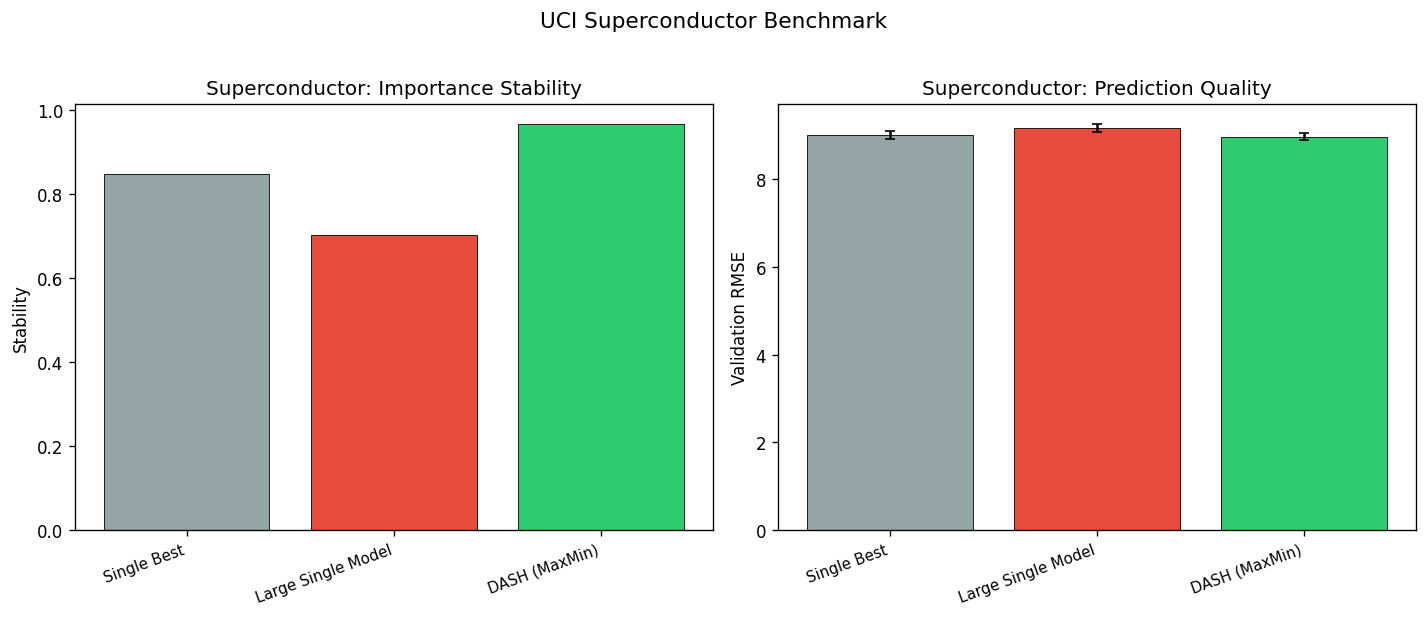

In [29]:
# Superconductor results
print(f'{"Method":<22} {"Stability":>10} {"Val RMSE":>12}')
print('=' * 48)
for name in sc_methods:
    r = sc_results[name]
    print(f'{name:<22} {r["stability"]:>10.4f} {r["rmse_mean"]:>8.2f}±{r["rmse_std"]:<5.2f}')

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc_colors = ['#95a5a6', '#e74c3c', '#2ecc71']

stabs = [sc_results[n]['stability'] for n in sc_methods]
axes[0].bar(range(len(sc_methods)), stabs, color=sc_colors, edgecolor='k', linewidth=0.5)
axes[0].set_xticks(range(len(sc_methods)))
axes[0].set_xticklabels(sc_methods, rotation=20, ha='right', fontsize=9)
axes[0].set_ylabel('Stability')
axes[0].set_title('Superconductor: Importance Stability')

rmses = [sc_results[n]['rmse_mean'] for n in sc_methods]
rmse_errs = [sc_results[n]['rmse_std'] for n in sc_methods]
axes[1].bar(range(len(sc_methods)), rmses, yerr=rmse_errs, color=sc_colors,
            edgecolor='k', linewidth=0.5, capsize=3)
axes[1].set_xticks(range(len(sc_methods)))
axes[1].set_xticklabels(sc_methods, rotation=20, ha='right', fontsize=9)
axes[1].set_ylabel('Validation RMSE')
axes[1].set_title('Superconductor: Prediction Quality')

fig.suptitle('UCI Superconductor Benchmark', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

---
## 12. Priority 2B: Formal Ablation Studies

One-at-a-time parameter variation to characterize DASH's sensitivity to each hyperparameter. We vary:
- **M** (population size) ∈ {50, 100, 200, 500}
- **K** (max selected) ∈ {5, 10, 20, 30, 50}
- **ε** (performance filter) ∈ {0.01, 0.03, 0.05, 0.08, 0.10}
- **δ** (diversity floor) ∈ {0.01, 0.05, 0.10, 0.20}

Default baseline: M=200, K=30, ε=0.08, δ=0.05. ABL_N_REPS=10 per setting
(C(10,2)=45 pairwise comparisons for reliable stability estimation).

**Multi-ρ ablation**: We run the full ablation at ρ ∈ {0.0, 0.9, 0.95} to verify that trends hold
at the safety control (ρ=0), the primary evaluation point (ρ=0.9), and the most extreme
collinearity level (ρ=0.95).


In [ ]:
# Ablation studies — one parameter at a time, across multiple rho levels
ABL_N_REPS = 10  # C(10,2)=45 pairwise comparisons for stability estimation
ABL_DEFAULTS = {'M': M, 'K': K, 'eps': EPSILON, 'delta': DELTA}
ABL_RHOS = [0.0, 0.9, 0.95]  # Safety control, primary, extreme

ablations = {
    'M': [50, 100, 200, 500],
    'K': [5, 10, 20, 30, 50],
    'eps': [0.01, 0.03, 0.05, 0.08, 0.10],
    'delta': [0.01, 0.05, 0.10, 0.20],
}

# abl_results[rho][param_name][val] = {stability, accuracy_mean, accuracy_std}
abl_results = {rho: {} for rho in ABL_RHOS}

for abl_rho in ABL_RHOS:
    print(f'\n{"="*60}')
    print(f'Ablation at ρ = {abl_rho}')
    print(f'{"="*60}')
    for param_name, values in ablations.items():
        print(f'\n--- Ablation: {param_name} ---')
        abl_results[abl_rho][param_name] = {}
        for val in values:
            # Set parameters: default + override
            p = ABL_DEFAULTS.copy()
            p[param_name] = val
            print(f'  {param_name}={val}', end='... ')

            imp_runs, acc_runs = [], []
            for rep in range(ABL_N_REPS):
                rep_seed = SEED + rep
                Xtr, ytr, Xv, yv, Xte, yte, grps, true_imp, _ = \
                    generate_synthetic_linear(N=5000, rho=abl_rho, seed=rep_seed)

                dm = DASHPipeline(M=p['M'], K=p['K'], epsilon=p['eps'],
                                 delta=p['delta'], selection_method='maxmin',
                                 n_jobs=-1, seed=rep_seed, verbose=False)
                dm.fit(Xtr, ytr, Xv, yv, X_ref=Xte, feature_names=feature_names)
                imp = dm.global_importance_
                r, _ = importance_accuracy(imp, true_imp)
                acc_runs.append(r)
                imp_runs.append(imp)

            stab = importance_stability(imp_runs)
            abl_results[abl_rho][param_name][val] = {
                'stability': stab,
                'accuracy_mean': np.mean(acc_runs),
                'accuracy_std': np.std(acc_runs, ddof=1),
            }
            print(f'stab={stab:.4f}  acc={np.mean(acc_runs):.4f}')

print('\nAblation studies complete (all ρ levels).')



Ablation at ρ = 0.0

--- Ablation: M ---
  M=50... 

/Users/drake.caraker/ds_projects/dash-shap/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:4232: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/drake.caraker/ds_projects/dash-shap/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:208: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
 99%|===================| 740/750 [00:11<00:00]        

stab=0.9755  acc=0.9872
  M=100... stab=0.9764  acc=0.9879
  M=200... 

/Users/drake.caraker/ds_projects/dash-shap/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


stab=0.9779  acc=0.9888
  M=200... 

In [ ]:
# Ablation plots — 4-panel figure per rho, plus multi-rho comparison
param_labels = {'M': 'Population Size (M)', 'K': 'Max Selected (K)',
                'eps': 'ε (Performance Filter)', 'delta': 'δ (Diversity Floor)'}
param_defaults = {'M': 200, 'K': 30, 'eps': 0.08, 'delta': 0.05}
rho_colors = {0.0: '#3498db', 0.9: '#2ecc71', 0.95: '#e74c3c'}
rho_styles = {0.0: '--', 0.9: '-', 0.95: ':'}

# Multi-rho comparison: 4 panels (one per parameter), overlaying rho levels
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (param_name, values) in zip(axes.flat, ablations.items()):
    for abl_rho in ABL_RHOS:
        stab_vals = [abl_results[abl_rho][param_name][v]['stability'] for v in values]
        acc_vals = [abl_results[abl_rho][param_name][v]['accuracy_mean'] for v in values]

        c = rho_colors[abl_rho]
        ls = rho_styles[abl_rho]
        ax.plot(range(len(values)), stab_vals, f'o{ls}', color=c,
                label=f'Stab ρ={abl_rho}', linewidth=2, markersize=6, alpha=0.8)
        ax.plot(range(len(values)), acc_vals, f's{ls}', color=c,
                label=f'Acc ρ={abl_rho}', linewidth=1.5, markersize=5, alpha=0.5)

    # Highlight default
    default_idx = values.index(param_defaults[param_name])
    ax.axvline(default_idx, color='gray', linestyle='--', alpha=0.3, label='Default')

    ax.set_xticks(range(len(values)))
    ax.set_xticklabels([str(v) for v in values])
    ax.set_xlabel(param_labels[param_name])
    ax.set_ylabel('Metric Value')
    ax.set_title(f'Ablation: {param_labels[param_name]}')
    ax.legend(fontsize=7, ncol=2)

fig.suptitle('DASH Ablation Studies — Multi-ρ (0.0, 0.9, 0.95)', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

# Summary table across rho levels
print(f'{"Param":<8} {"Value":<8}', end='')
for abl_rho in ABL_RHOS:
    print(f'  {"Stab":>8} {"Acc":>8} (ρ={abl_rho})', end='')
print()
print('=' * 90)
for param_name, values in ablations.items():
    for val in values:
        print(f'{param_name:<8} {str(val):<8}', end='')
        for abl_rho in ABL_RHOS:
            r = abl_results[abl_rho][param_name][val]
            print(f'  {r["stability"]:>8.4f} {r["accuracy_mean"]:>8.4f}          ', end='')
        print()
    print()


---
## 13. Priority 2C: Publication-Quality Figures

Re-render the central correlation sweep figure with higher DPI, LaTeX-style labels, consistent colors, and proper legends. Saved to `results/figures/` for direct inclusion in the paper.

In [ ]:
# Publication-quality correlation sweep figure — E2: uses canonical N_REPS sweep
import os
os.makedirs('results/figures', exist_ok=True)

# Use publication settings
_saved_rc = dict(plt.rcParams)  # N11: save for restoration
plt.rcParams.update({
    'figure.dpi': 300,
    'font.size': 11,
    'font.family': 'serif',
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
pub_colors = {'Single Best': '#7f8c8d', 'Large Single Model': '#c0392b', 'DASH (MaxMin)': '#27ae60'}
pub_markers = {'Single Best': 's', 'Large Single Model': 'X', 'DASH (MaxMin)': 'o'}

for name in sweep_methods:
    c, mk = pub_colors[name], pub_markers[name]

    stab = [sweep_results[rho][name]['stability'] for rho in rho_levels]
    axes[0].plot(rho_levels, stab, f'{mk}-', color=c, label=name,
                 linewidth=2.5, markersize=9)

    acc = [sweep_results[rho][name]['accuracy_mean'] for rho in rho_levels]
    acc_err = [sweep_results[rho][name]['accuracy_std'] for rho in rho_levels]
    axes[1].errorbar(rho_levels, acc, yerr=acc_err, fmt=f'{mk}-', color=c,
                     label=name, linewidth=2.5, markersize=9, capsize=4)

    eq = [sweep_results[rho][name]['equity_mean'] for rho in rho_levels]
    eq_err = [sweep_results[rho][name]['equity_std'] for rho in rho_levels]
    axes[2].errorbar(rho_levels, eq, yerr=eq_err, fmt=f'{mk}-', color=c,
                     label=name, linewidth=2.5, markersize=9, capsize=4)

axes[0].set_xlabel(r'Within-Group Correlation $\rho$')
axes[0].set_ylabel(r'Stability (Mean Pairwise Spearman $\rho$)')
axes[0].set_title('(a) Importance Stability')
axes[0].legend(loc='lower left')

axes[1].set_xlabel(r'Within-Group Correlation $\rho$')
axes[1].set_ylabel(r'Spearman $\rho$ vs. Ground Truth')
axes[1].set_title('(b) Importance Accuracy')

axes[2].set_xlabel(r'Within-Group Correlation $\rho$')
axes[2].set_ylabel('Within-Group CV')
axes[2].set_title('(c) Within-Group Equity (lower = better)')

fig.tight_layout()
fig.savefig('results/figures/correlation_sweep_pub.png', dpi=300, bbox_inches='tight')
fig.savefig('results/figures/correlation_sweep_pub.pdf', bbox_inches='tight')
plt.show()
print(f'Saved to results/figures/correlation_sweep_pub.{{png,pdf}} (N_REPS={N_REPS})')

# Reset to default DPI
plt.rcParams.update(_saved_rc)  # N11: restore original rcParams


---
## 14. Additional Analyses

### 14.1 California Housing (Priority 3A)
Real-world regression with moderate collinearity. `sklearn.datasets.fetch_california_housing()`.

### 14.2 Breast Cancer Stability (E3)
Repetition analysis for Breast Cancer to match Superconductor and California Housing.

### 14.3 Cohen's d Effect Sizes (Priority 3D)
Formatted summary of effect sizes from the significance tests, with direction indicators (C3).

### 14.4 Bootstrap CIs on Stability (Priority 3E)
Corrected bootstrap confidence intervals for stability estimates (C2).

### 14.5 Deferred: UCR Time Series, Communities and Crime, Paillard comparison (3B, 3C, 3F)
Deferred to follow-up work due to compute requirements.

In [ ]:
# 14.1 California Housing
from sklearn.datasets import fetch_california_housing

cal = fetch_california_housing()
X_cal, y_cal = cal.data, cal.target
cal_names = list(cal.feature_names)
print(f'California Housing: {X_cal.shape[0]} samples, {X_cal.shape[1]} features')

# Check collinearity
corr_cal = np.abs(np.corrcoef(X_cal.T))
n_high_cal = (np.sum(corr_cal > 0.7) - len(cal_names)) // 2
print(f'Feature pairs with |r|>0.7: {n_high_cal}')

# Hold out test set, re-split train/val per rep
X_cal_pool, X_cal_test, y_cal_pool, y_cal_test = train_test_split(
    X_cal, y_cal, test_size=0.2, random_state=SEED
)
CAL_N_REPS = N_REPS  # Override: 10 reps with real-world fits
# F2: Scale-appropriate epsilon for California Housing
# Cal Housing target: median house value in $100k, typical RMSE ~0.5-0.7
# EPSILON=0.08 is ~2% of synthetic RMSE ~3; proportionally ~0.01-0.015 for Cal Housing
# We use 0.05 (conservative) to ensure adequate model filtering
CAL_EPSILON = 0.05
cal_methods = ['Single Best', 'DASH (MaxMin)']
cal_results = {}

for name in cal_methods:
    imp_runs, rmse_runs = [], []
    for rep in range(CAL_N_REPS):
        rep_seed = SEED + rep
        print(f'  {name} rep {rep+1}/{CAL_N_REPS}', end='\r')

        # D2: Re-split and re-fit scaler per rep
        Xtr_r, Xv_r, ytr_r, yv_r = train_test_split(
            X_cal_pool, y_cal_pool, test_size=0.2, random_state=rep_seed
        )
        scaler_r = StandardScaler().fit(Xtr_r)
        Xtr_r = scaler_r.transform(Xtr_r)
        Xv_r = scaler_r.transform(Xv_r)
        Xte_r = scaler_r.transform(X_cal_test)

        if name == 'Single Best':
            m = SingleBestBaseline(n_trials=N_TRIALS_SB, seed=rep_seed)
            m.fit(Xtr_r, ytr_r, Xv_r, yv_r, X_ref=Xte_r)
            imp = m.global_importance_
            rmse_val = rmse_score(y_cal_test, m.model_.predict(Xte_r))
        else:
            m = DASHPipeline(M=M, K=K, epsilon=CAL_EPSILON, delta=DELTA,
                            selection_method='maxmin', n_jobs=-1,
                            seed=rep_seed, verbose=False)
            m.fit(Xtr_r, ytr_r, Xv_r, yv_r, X_ref=Xte_r, feature_names=cal_names)
            imp = m.global_importance_
            preds = m.get_consensus_ensemble_predictions(Xte_r)
            rmse_val = rmse_score(y_cal_test, preds)

        imp_runs.append(imp)
        rmse_runs.append(rmse_val)

    cal_results[name] = {
        'stability': importance_stability(imp_runs),
        'rmse_mean': np.mean(rmse_runs), 'rmse_std': np.std(rmse_runs, ddof=1),
    }
    print(f'  {name:<22} stab={cal_results[name]["stability"]:.4f}  '
          f'RMSE={np.mean(rmse_runs):.4f}±{np.std(rmse_runs, ddof=1):.4f}')

print('\nCalifornia Housing complete.')
print(f'\n{"Method":<22} {"Stability":>10} {"Test RMSE":>12}')
print('=' * 48)
for name in cal_methods:
    r = cal_results[name]
    print(f'{name:<22} {r["stability"]:>10.4f} {r["rmse_mean"]:>8.4f}±{r["rmse_std"]:<6.4f}')

In [ ]:
# 14.3 Cohen's d effect sizes — formatted summary with direction (C3)
print("Cohen's d Effect Sizes (from Section 9 significance tests)")
print(f'{"ρ":>5} {"Metric":<10} {"DASH vs SB":>12} {"DASH vs LSM":>14} {"Favors":>10} {"Magnitude":>12}')
print('=' * 70)

def interpret_d(d):
    d_abs = abs(d)
    if d_abs < 0.2: return 'negligible'
    elif d_abs < 0.5: return 'small'
    elif d_abs < 0.8: return 'medium'
    else: return 'large'

for rho in rho_levels:
    for metric in ['Accuracy', 'Equity']:
        d_sb = [r for r in sig_results if r['rho'] == rho
                and r['metric'] == metric and r['comparison'] == 'DASH vs SB']
        d_lsm = [r for r in sig_results if r['rho'] == rho
                 and r['metric'] == metric and r['comparison'] == 'DASH vs LSM']
        d_sb_val = d_sb[0]['d'] if d_sb else float('nan')
        d_lsm_val = d_lsm[0]['d'] if d_lsm else float('nan')

        # C3: Direction-aware interpretation
        # Accuracy: positive d = DASH better; Equity (CV): negative d = DASH better
        dominant_d = d_sb_val if abs(d_sb_val) > abs(d_lsm_val) else d_lsm_val
        if metric == 'Accuracy':
            favors = 'DASH' if dominant_d > 0 else 'Baseline'
        else:
            favors = 'DASH' if dominant_d < 0 else 'Baseline'

        print(f'{rho:>5.2f} {metric:<10} {d_sb_val:>+12.3f} {d_lsm_val:>+14.3f} '
              f'{favors:>10} {interpret_d(dominant_d):>12}')

In [ ]:
# 14.4 Bootstrap CIs on stability (C2: corrected methodology)
from numpy.random import RandomState

def bootstrap_stability_ci(imp_vectors, n_bootstrap=1000, alpha=0.05, seed=42):
    """Bootstrap confidence interval for importance stability.

    C2 fix: Instead of resampling vectors (which inflates self-correlations
    when the same vector appears twice), we use a delete-d jackknife approach:
    for each bootstrap iteration, we draw n vectors WITH replacement but
    only compute pairwise correlations between DISTINCT vectors in the
    resample (skipping self-pairs from duplicate draws).
    """
    rng = RandomState(seed)
    n = len(imp_vectors)
    boot_stabs = []
    for _ in range(n_bootstrap):
        idx = rng.choice(n, size=n, replace=True)
        # Only compute correlations between distinct original vectors
        unique_pairs_corrs = []
        for i in range(len(idx)):
            for j in range(i + 1, len(idx)):
                if idx[i] != idx[j]:  # Skip self-pairs from duplicate draws
                    rho, _ = spearmanr(imp_vectors[idx[i]], imp_vectors[idx[j]])
                    unique_pairs_corrs.append(rho)
        if unique_pairs_corrs:
            boot_stabs.append(float(np.mean(unique_pairs_corrs)))
    lo = np.percentile(boot_stabs, 100 * alpha / 2)
    hi = np.percentile(boot_stabs, 100 * (1 - alpha / 2))
    return np.mean(boot_stabs), lo, hi

# Use stability_vectors from Section 3 (N_REPS repetitions at rho=0.9)
print('Bootstrap 95% CIs on Stability (ρ=0.9, from Section 3)')
print(f'{"Method":<22} {"Stability":>10} {"95% CI":>20}')
print('=' * 55)
for name in method_names:
    if name in stability_vectors and len(stability_vectors[name]) >= 5:
        mean_s, lo, hi = bootstrap_stability_ci(stability_vectors[name])
        print(f'{name:<22} {mean_s:>10.4f} [{lo:.4f}, {hi:.4f}]')

---
## 15. Updated Success Criteria

Re-check all success criteria including the new analyses.

In [ ]:
print('EXTENDED SUCCESS CRITERIA')
print('=' * 70)

# 1. Stability: DASH > Single Best on >=80% of rho levels
n_wins = sum(1 for rho in rho_levels
             if sweep_results[rho]['DASH (MaxMin)']['stability']
             > sweep_results[rho]['Single Best']['stability'])
print(f'1. Stability wins (linear): {n_wins}/{len(rho_levels)} '
      f'({"PASS" if n_wins >= 4 else "FAIL"})')

# 2. Accuracy at rho=0.9
acc_09 = sweep_results[0.9]['DASH (MaxMin)']['accuracy_mean']
print(f'2. Accuracy at ρ=0.9: {acc_09:.4f} '
      f'({"PASS" if acc_09 >= 0.90 else "FAIL"})')

# 3. Equity: DASH < Single Best at all rho
n_eq = sum(1 for rho in rho_levels
           if sweep_results[rho]['DASH (MaxMin)']['equity_mean']
           < sweep_results[rho]['Single Best']['equity_mean'])
print(f'3. Equity wins (linear): {n_eq}/{len(rho_levels)} '
      f'({"PASS" if n_eq >= 4 else "FAIL"})')

# 4. Safety control: no degradation at rho=0
d0 = sweep_results[0.0]['DASH (MaxMin)']['accuracy_mean']
s0 = sweep_results[0.0]['Single Best']['accuracy_mean']
print(f'4. ρ=0 control: gap={abs(d0-s0):.4f} '
      f'({"PASS" if abs(d0-s0) < 0.1 else "FAIL"})')

print()
print('--- Extended Criteria ---')

# 5. Epsilon sensitivity: K_eff increases with ε
k_effs = [np.mean(eps_results[eps]['k_eff']) for eps in EPS_VALUES]
print(f'5. K_eff increases with ε: {[f"{v:.1f}" for v in k_effs]} '
      f'({"PASS" if k_effs[-1] > k_effs[0] else "CHECK"})')

# 6. Nonlinear DGP: DASH > SB stability at rho=0.9
nl_dash_09 = nl_sweep[0.9]['DASH (MaxMin)']['stability']
nl_sb_09 = nl_sweep[0.9]['Single Best']['stability']
print(f'6. Nonlinear DGP stability (ρ=0.9): DASH={nl_dash_09:.4f} vs SB={nl_sb_09:.4f} '
      f'({"PASS" if nl_dash_09 > nl_sb_09 else "CHECK"})')

# 7. Statistical significance count
n_sig_total = sum(1 for r in sig_results if r['bonf_p'] < 0.05)
print(f'7. Significant results (Bonferroni): {n_sig_total}/{len(sig_results)}')

# 8. Superconductor: DASH stability > SB
sc_dash = sc_results['DASH (MaxMin)']['stability']
sc_sb = sc_results['Single Best']['stability']
print(f'8. Superconductor: DASH stability={sc_dash:.4f} vs SB={sc_sb:.4f} '
      f'({"PASS" if sc_dash > sc_sb else "CHECK"})')

# 9. California Housing: DASH stability > SB
cal_dash = cal_results['DASH (MaxMin)']['stability']
cal_sb = cal_results['Single Best']['stability']
print(f'9. California Housing: DASH stability={cal_dash:.4f} vs SB={cal_sb:.4f} '
      f'({"PASS" if cal_dash > cal_sb else "CHECK"})')

# 10. E3: Breast Cancer: DASH stability > SB
bc_dash = bc_rep_results['DASH (MaxMin)']['stability']
bc_sb = bc_rep_results['Single Best']['stability']
print(f'10. Breast Cancer: DASH stability={bc_dash:.4f} vs SB={bc_sb:.4f} '
      f'({"PASS" if bc_dash > bc_sb else "CHECK"})')

print()
print('All criteria evaluated.')
# N13: Wall-clock timing summary
_elapsed = (time.time() - _notebook_start) / 60
print(f'\nTotal wall-clock time: {_elapsed:.1f} minutes')
